Импорты, чтение предобработанных данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
from geopy.distance import geodesic
from scipy import stats
from scipy.stats import norm
import json

try:
    import pingouin
except ImportError:
    !pip install pingouin
    import pingouin

try:
    import shapely
except ImportError:
    !pip install shapely
    import shapely

try:
    import geopy
except ImportError:
    !pip install geopy
    import geopy

try:
    import folium
except ImportError:
    !pip install folium
    import folium

try:
    import branca
except ImportError:
    !pip install branca
    import branca

from shapely.geometry import shape, Point
from shapely.ops import unary_union, polygonize

from scipy.stats import ttest_ind, f_oneway, levene, shapiro
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings

df_path = 'insert_path'

# Андрей

In [143]:
warnings.filterwarnings('ignore', message="have mixed types")

In [144]:
df = pd.read_csv(df_path)

df_work = df.copy()
df_work = df_work.drop(columns=[
    'url', 'address', 'highway_info', 'description',
    'photos_url', 'seller', 'publication_date', 'request_time',
    'auction', 'accident_rate', 'floor_type'
])

line_to_stations = {
    'Сокольническая (1)': {
        'бульвар рокоссовского','черкизовская','преображенская площадь','сокольники',
        'красносельская','комсомольская','красные ворота','чистые пруды','лубянка',
        'охотный ряд','библиотека имени ленина','кропоткинская','парк культуры',
        'фрунзенская','спортивная','воробьёвы горы','университет','проспект вернадского',
        'юго-западная','тропарёво','румянцево','саларьево','филатов луг','прокшино',
        'ольховая','новомосковская','потапово','улица горчакова','остафьево',
    },
    'Замоскворецкая (2)': {
        'ховрино','беломорская','речной вокзал','водный стадион','войковская','сокол',
        'аэропорт','динамо','белорусская','маяковская','тверская','театральная',
        'новокузнецкая','павелецкая','автозаводская','технопарк','коломенская',
        'каширская','кантемировская','царицыно','орехово','домодедовская',
        'красногвардейская','алма-атинская',
    },
    'Арбатско-Покровская (3)': {
        'гольяново','щёлковская','первомайская','измайловская','партизанская',
        'семёновская','электрозаводская','бауманская','курская','площадь революции',
        'арбатская','смоленская','киевская','парк победы','славянский бульвар',
        'кунцевская','молодёжная','крылатское','строгино','мякинино','волоколамская',
        'митино','пятницкое шоссе',
    },
    'Филёвская (4)': {
        'александровский сад','арбатская','смоленская','киевская','студенческая',
        'кутузовская','фили','багратионовская','филёвский парк','пионерская',
        'кунцевская','деловой центр','москва-сити',
    },
    'Кольцевая (5)': {
        'киевская','краснопресненская','белорусская','новослободская','достоевская',
        'проспект мира','комсомольская','курская','таганская','павелецкая',
        'добрынинская','октябрьская','парк культуры',
    },
    'Калужско-Рижская (6)': {
        'медведково','бабушкинская','свиблово','ботанический сад','вднх',
        'алексеевская','рижская','проспект мира','сухаревская','тургеневская',
        'китай-город','третьяковская','октябрьская','шаболовская','ленинский проспект',
        'академическая','профсоюзная','новые черёмушки','калужская','беляево',
        'коньково','тёплый стан','ясенево','новоясеневская',
    },
    'Таганско-Краснопресненская (7)': {
        'планерная','сходненская','тушинская','спартак','щукинская','октябрьское поле',
        'полежаевская','беговая','улица 1905 года','баррикадная','пушкинская',
        'кузнецкий мост','китай-город','таганская','пролетарская',
        'волгоградский проспект','текстильщики','кузьминки','рязанский проспект',
        'выхино','лермонтовский проспект','жулебино','котельники',
    },
    'Калининская (8)': {
        'новокосино','новогиреево','перово','шоссе энтузиастов','авиамоторная',
        'площадь ильича','марксистская','третьяковская',
    },
    'Солнцевская (8А)': {
        'деловой центр','парк победы','минская','ломоносовский проспект','раменки',
        'мичуринский проспект','озёрная','говорово','солнцево','боровское шоссе',
        'новопеределкино','рассказовка','пыхтино','аэропорт внуково',
    },
    'Серпуховско-Тимирязевская (9)': {
        'алтуфьево','бибирево','отрадное','владыкино','петровско-разумовская',
        'тимирязевская','дмитровская','савёловская','менделеевская','цветной бульвар',
        'чеховская','боровицкая','полянка','серпуховская','тульская','нагатинская',
        'нагорная','нахимовский проспект','севастопольская','чертановская','южная',
        'пражская','улица академика янгеля','аннино','бульвар дмитрия донского',
    },
    'Люблинско-Дмитровская (10)': {
        'физтех','лианозово','яхромская','селигерская','верхние лихоборы','окружная',
        'петровско-разумовская','фонвизинская','бутырская','марьина роща',
        'достоевская','трубная','сретенский бульвар','чкаловская','римская',
        'крестьянская застава','дубровка','кожуховская','печатники','волжская',
        'люблино','братиславская','марьино','борисово','шипиловская','зябликово',
    },
    'БКЛ (11)': {
        'хорошёвская','цска','петровский парк','савёловская','марьина роща',
        'рижская','сокольники','электрозаводская','лефортово','авиамоторная',
        'нижегородская','текстильщики','печатники','нагатинский затон',
        'кленовый бульвар','каширская','варшавская','каховская','зюзино',
        'воронцовская','новаторская','проспект вернадского','мичуринский проспект',
        'аминьевская','давыдково','кунцевская','терехово','мнёвники',
        'народное ополчение',
    },
    'Бутовская (12)': {
        'битцевский парк','лесопарковая','улица старокачаловская','улица скобелевская',
        'бульвар адмирала ушакова','улица горчакова','бунинская аллея',
    },
    'МЦК (14)': {
        'окружная','владыкино','ботанический сад','ростокино','белокаменная',
        'бульвар рокоссовского','локомотив','измайлово','соколиная гора',
        'шоссе энтузиастов','нижегородская','новохохловская','угрешская',
        'дубровка','автозаводская','зил','верхние котлы','крымская',
        'площадь гагарина','лужники','кутузовская','москва-сити','шелепиха',
        'хорошёво','зорге','панфиловская','стрешнево','балтийская','коптево','лихоборы',
    },
    'Некрасовская (15)': {
        'нижегородская','стахановская','окская','юго-восточная','косино',
        'улица дмитриевского','лухмановская','некрасовка',
    },
    'Троицкая (16)': {
        'зил','крымская','академическая','вавиловская','новаторская',
        'университет дружбы народов','генерала тюленева','тютчевская','корниловская',
        'коммунарка','новомосковская','десна','кедровая','ватутинки','троицк',
        'солнечная',
    },
    'Рублёво-Архангельская (17)': {
        'деловой центр','шелепиха','народное ополчение','бульвар генерала карбышева',
        'серебряный бор','строгино', 'звенигородская', 'звенигородская', 'красногорская'
    },
    'Бирюлёвская (18)': {
        'зил','кленовый бульвар','курьяново','москворечье','каспийская','липецкая',
        'лебедянская','бирюлёво','остафьево','щербинка','кедровая','кавказский бульвар',
    },
    'МЦД1': {
        'сетунь','рабочий посёлок','беговая','белорусская','савёловская','дмитровская',
        'тимирязевская','петровско-разумовская','окружная','дегунино','бескудниково',
        'лианозово','марк','долгопрудная',
    },
    'МЦД2': {
        'бутово','павшино','пенягино','волоколамская','трикотажная','тушинская',
        'щукинская','стрешнево','красный балтиец','гражданская','дмитровская',
        'марьина роща','рижская','площадь трёх вокзалов','курская','москва-товарная',
        'калитники','новохохловская','текстильщики','печатники','люблино','депо',
        'перерва','курьяново','москворечье','царицыно','покровское','красный строитель',
        'битца','щербинка','остафьево','силикатная','подольск',
    },
    'МЦД3': {
        'зеленоград — крюково','фирсановская','подрезково','новоподрезково',
        'молжаниново','химки','грачёвская','моссельмаш','лихоборы',
        'петровско-разумовская','останкино','рижская','электрозаводская',
        'сортировочная','авиамоторная','перово','плющево','вешняки','выхино',
        'косино','ухтомская','люберцы', 'сходня',
    },
    'МЦД4': {
        'новогиреево','кусково','чухлинка','нижегородская','серп и молот',
        'курская','площадь трёх вокзалов','рижская','марьина роща','савёловская',
        'белорусская','беговая','москва-сити','кутузовская','поклонная','минская',
        'матвеевская','аминьевская','очаково','новопеределкино','переделкино',
        'мичуринец','толстопальцево','кокошкино','санино','крёкшино', "мещерская"
    },
    'МЦД5': {
        'физтех','яхромская','ростокино','рижская','тульская','верхние котлы',
        'нагатинская','варшавская','царицыно','курьяново','остафьево','щербинка',
    },
}

station_to_lines = {}
for line, stations in line_to_stations.items():
    for s in stations:
        station_to_lines.setdefault(s, []).append(line)

SKIP_LINES = {'Кольцевая (5)', 'БКЛ (11)'}

def parse_nearest_station(metro_info):
    if not isinstance(metro_info, str):
        return None
    cleaned = re.sub(r',?\s*откроется в \d+', '', metro_info)
    matches = re.findall(r'([а-яёА-ЯЁ\s\-]+),\s*(\d+)\s*мин', cleaned)
    if not matches:
        return None
    nearest = min(matches, key=lambda x: int(x[1]))
    return nearest[0].strip().lower()

def get_transport_type(station):
    lines = station_to_lines.get(station, [])
    if not lines:
        return 'Другое'
    if any('МЦД' not in l and 'МЦК' not in l for l in lines):
        return 'Метро'
    if any('МЦК' in l for l in lines):
        return 'МЦК'
    return 'МЦД'

def get_primary_line(station):
    lines = station_to_lines.get(station, [])
    if not lines:
        return None
    metro_lines = [l for l in lines if 'МЦД' not in l and 'МЦК' not in l]
    preferred   = [l for l in metro_lines if l not in SKIP_LINES]
    return (preferred or metro_lines or lines)[0]

mask = df_work['nearest_station'].isna()
df_work.loc[mask, 'nearest_station'] = df['metro_info'][mask].map(parse_nearest_station)

df_work['station_transport'] = df_work['nearest_station'].map(get_transport_type)
df_work['station_line']      = df_work['nearest_station'].map(get_primary_line)

print(df_work['station_transport'].value_counts())
unknown = df_work[df_work['station_transport'] == 'Другое']['nearest_station'].dropna().unique()
print("Другое:", sorted(unknown))

station_transport
Метро     23882
МЦД        3248
МЦК         998
Другое       57
Name: count, dtype: int64
Другое: []


### Гипотеза 1

H0: Средняя стоимость квадратного метра для всех веток метро одинакова H1: Средняя стоимость кв. метра хотя бы для одной ветки значимо отличается от остальных

Введем меру цены за квадратный метр и исключим из сравнения тип транспорта МЦД, так как это не метро.

Посмотрим основные параметры: медиану, среднее, стандартное отклонение.

In [145]:
import matplotlib.ticker as mticker
import pingouin as pg

df_work = df_work[~df_work.station_line.isin(['МЦК (14)', 'МЦД1', 'МЦД2', 'МЦД3', 'МЦД4'])]
df_work['price_per_m2'] = df_work['price'] / df_work['total_area']

TARGET = 'price_per_m2'
GROUP  = 'station_line'

df = df_work[[GROUP, TARGET]].dropna()

n_groups = df[GROUP].nunique()
n_total  = len(df)

groups_dict = {name: grp[TARGET].values for name, grp in df.groupby(GROUP)}
groups_list = list(groups_dict.values())

desc = df.groupby(GROUP)[TARGET].agg(
    n='count',
    median='median',
    mean='mean',
    std='std'
).sort_values('median', ascending=False)

print(f"Групп: {n_groups}   |   Наблюдений: {n_total:,}\n")

desc.style.format({'n': '{:,}', 'median': '{: ,.0f}', 'mean': '{: ,.0f}', 'std': '{: ,.0f}'})

Групп: 17   |   Наблюдений: 23,882



,n,median,mean,std
station_line,,,,
Кольцевая (5),60,"577,493","616,393","147,729"
Филёвская (4),557,"550,351","573,397","143,703"
БКЛ (11),"2,063","519,350","526,128","120,848"
Рублёво-Архангельская (17),765,"508,156","539,757","151,926"
Замоскворецкая (2),"2,430","446,960","500,890","206,092"
Троицкая (16),746,"429,821","440,984","145,840"
Таганско-Краснопресненская (7),"2,059","426,966","446,073","141,094"
Серпуховско-Тимирязевская (9),"2,240","413,886","443,680","147,427"
Калужско-Рижская (6),"2,280","411,274","447,536","139,563"


Как видно, размеры групп различаются достаточно сильно, как и цены - медианы и среднее изменяются соответственно между ветками, разрыв более 250 тыс.

Проверим нормальность распределения внутри групп через qq графики

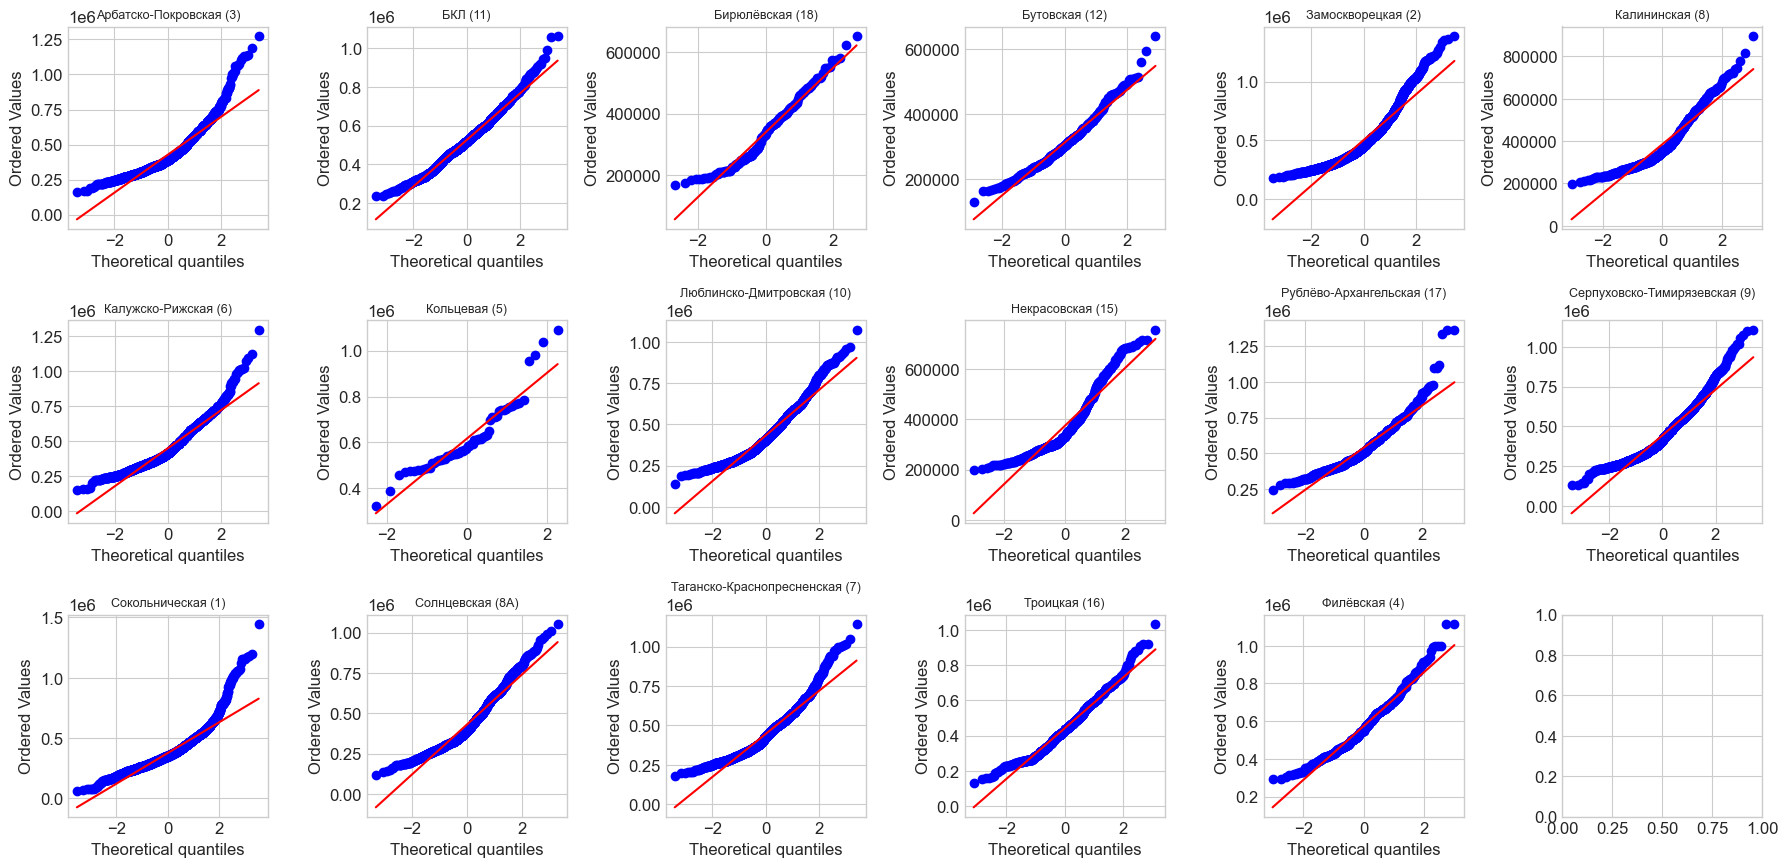

In [146]:
import scipy.stats as stats

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for i, (name, vals) in enumerate(groups_dict.items()):
    stats.probplot(vals, plot=axes[i])
    axes[i].set_title(name, fontsize=9)

plt.tight_layout()
plt.show()

Хоть и края явно задраны у всех групп, можно использовать ANOVA тест. Дополнительно проверим нормальность распределения остатков дисперсий тестом Левена.
Это определит тип ANOVA теста - либо классическая, либо ANOVA Уэлча как более устойчивый к сильно неоднородным дисперсиям.

In [147]:
pg.homoscedasticity(data=df, dv=TARGET, group=GROUP)

,W,pval,equal_var
levene,49.170591,1.952911e-154,False


In [148]:
lev_stat, lev_p = stats.levene(*groups_list)

print(f"Тест Левена:  W = {lev_stat},  p = {lev_p}")

Тест Левена:  W = 49.17059137546141,  p = 1.95291074682782e-154


Можно уверенно сказать, что дисперсии неоднородны.
Проведем ANOVA тест Уэлча. Уровень значимости, как на этом тесте, так и на всех последующих выберем 5%

In [149]:
anova_res = pg.welch_anova(data=df, dv=TARGET, between=GROUP)

p_col = next(c for c in anova_res.columns if c.startswith('p'))

F_val = anova_res['F'].iloc[0]
p_val = anova_res[p_col].iloc[0]
eta2  = anova_res['np2'].iloc[0]

print('ANOVA Уэлча, статистики: ')
print(f"F={F_val}, p={p_val}, eta2={eta2}")
print(f"{'влияет' if p_val < 0.05 else 'не влияет'}, объясняет {eta2*100:.2f}% дисперсии")

ANOVA Уэлча, статистики: 
F=266.0015060765145, p=0.0, eta2=0.11783445430283673
влияет, объясняет 11.78% дисперсии


Результаты ANOVA теста: F значение крайне высокое, дисперсия между группами сильно отличается от дисперсий внутри, вероятность получить такие или более выраженные результаты при том, что средние групп не отличаются, 0, объясняемая доля дисперсии данным фактором примерно 10.5%.

Проведем "пост-хок" - убедимся в результатах через попарный тест Геймса-Ховелла.
Он выбран так как устойчив к разным размерам выборок и равенства дисперсий.

пар всего: 136, значимых: 114
                          A                              B       diff  pval
0   Арбатско-Покровская (3)                       БКЛ (11)  -98608.30  0.00
3   Арбатско-Покровская (3)             Замоскворецкая (2)  -73370.58  0.00
8   Арбатско-Покровская (3)              Некрасовская (15)   54414.05  0.00
9   Арбатско-Покровская (3)     Рублёво-Архангельская (17) -112236.65  0.00
23                 БКЛ (11)              Некрасовская (15)  153022.36  0.00
..                      ...                            ...        ...   ...
82     Калужско-Рижская (6)     Люблинско-Дмитровская (10)   16022.63  0.01
93            Кольцевая (5)     Рублёво-Архангельская (17)   76636.65  0.02
10  Арбатско-Покровская (3)  Серпуховско-Тимирязевская (9)  -16160.08  0.03
37         Бирюлёвская (18)              Некрасовская (15)  -33758.44  0.03
87     Калужско-Рижская (6)               Солнцевская (8А)   18186.88  0.03

[114 rows x 4 columns]


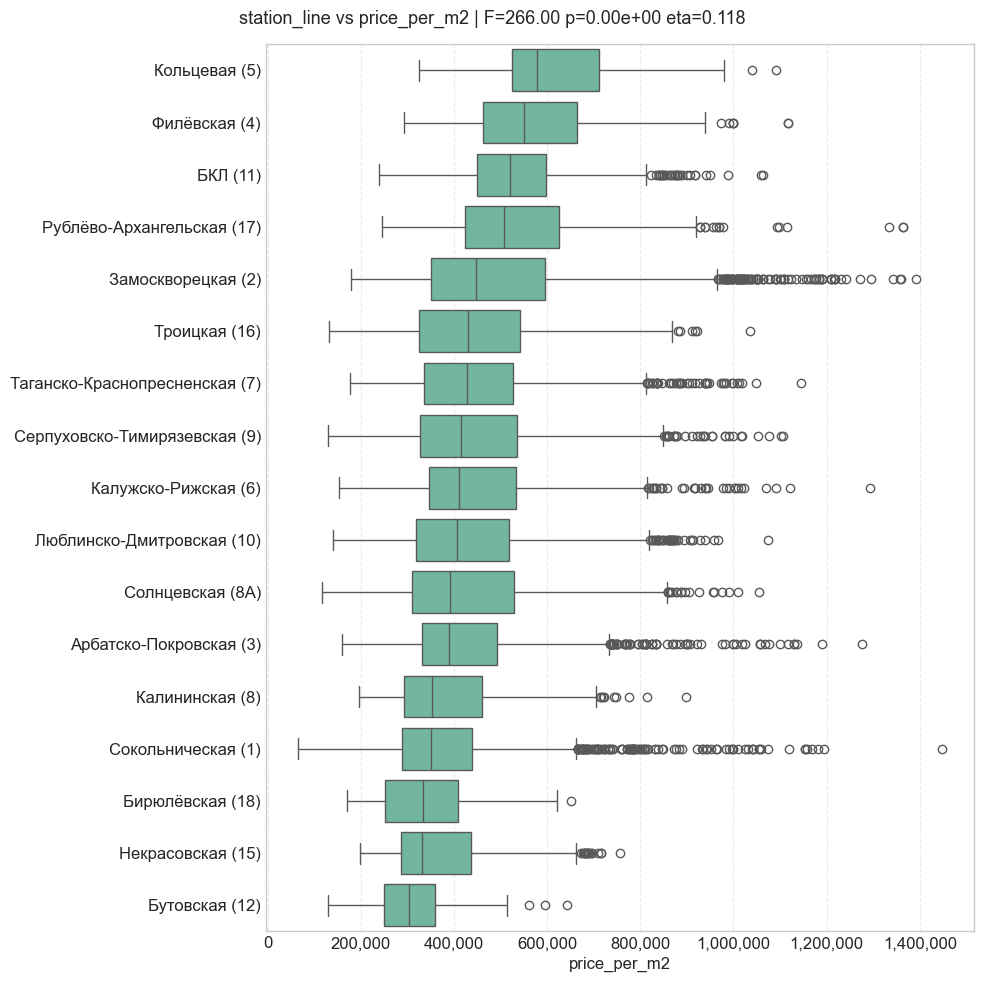

In [150]:
import seaborn as sns

posthoc = pg.pairwise_gameshowell(data=df, dv=TARGET, between=GROUP)

means = df.groupby(GROUP)[TARGET].mean().to_dict()
posthoc['mean_A'] = posthoc['A'].map(means)
posthoc['mean_B'] = posthoc['B'].map(means)

sig = posthoc[posthoc['pval'] < 0.05].sort_values('pval')
print(f"пар всего: {len(posthoc)}, значимых: {len(sig)}")

print(sig[['A', 'B',  'diff', 'pval']].round(2))

order = df.groupby(GROUP)[TARGET].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle(f"{GROUP} vs {TARGET} | F={F_val:.2f} p={p_val:.2e} eta={eta2:.3f}", fontsize=13)

sns.boxplot(data=df, y=GROUP, x=TARGET, order=order, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Как видим, для большинства пар различия значимы.
Для полной уверенности проведем еще и тест Краскала-Уоллиса, тоже устойчивый к неоднородности распределений так как работает с рангами

In [151]:
kw_stat, kw_p = stats.kruskal(*groups_list)

print(f"H = {kw_stat:.3f},  p = {kw_p:.2e}")

H = 3280.557,  p = 0.00e+00


Данный тест тоже показывает крайне высокое значение статистики и низкое pval. Интерпретируется похожим образом, что раньше: высокое значение статистики означает высокое различие между диспрерсиями, pval наличие такого же или более выраженного рез-тата если дисперсии были бы равны.

Окончательно, сделаем попарный T-Test и испольщуем 2 поправки: строгую Бонферрони вместе с Бенджамини-Хохберга, сравним количество с Геймсом-Ховеллом

In [152]:
from statsmodels.stats.multitest import multipletests

pairs, pvals_raw = [], []
for i, a in enumerate(order):
    for b in order[i+1:]:
        t, p = stats.ttest_ind(groups_dict[a], groups_dict[b], equal_var=False)
        pairs.append((a, b))
        pvals_raw.append(p)

_, pvals_bh,   _, _ = multipletests(pvals_raw, method='fdr_bh')
_, pvals_bonf, _, _ = multipletests(pvals_raw, method='bonferroni')

ttest_df = pd.DataFrame(pairs, columns=['A', 'B'])
ttest_df['p_raw']  = pvals_raw
ttest_df['p_bh']   = pvals_bh
ttest_df['p_bonf'] = pvals_bonf
ttest_df['mean_A'] = ttest_df['A'].map(means)
ttest_df['mean_B'] = ttest_df['B'].map(means)
ttest_df['diff']   = ttest_df['mean_A'] - ttest_df['mean_B']

sig_ttest = ttest_df[ttest_df['p_bh'] < 0.05].sort_values('p_bh')

print(f"пар всего: {len(ttest_df)}")
print(f"значимых BH:         {(ttest_df['p_bh']   < 0.05).sum()}")
print(f"значимых Бонферрони: {(ttest_df['p_bonf'] < 0.05).sum()}")
print(f"значимых в GH:       {len(sig)}")

display(sig_ttest[['A', 'B', 'mean_A', 'mean_B', 'diff', 'p_raw', 'p_bh', 'p_bonf']].round(2))

пар всего: 136
значимых BH:         122
значимых Бонферрони: 114
значимых в GH:       114


,A,B,mean_A,mean_B,diff,p_raw,p_bh,p_bonf
41,БКЛ (11),Сокольническая (1),526128.17,376470.62,149657.55,0.00,0.00,0.00
44,БКЛ (11),Бутовская (12),526128.17,313188.49,212939.67,0.00,0.00,0.00
30,Филёвская (4),Бутовская (12),573397.09,313188.49,260208.59,0.00,0.00,0.00
57,Рублёво-Архангельская (17),Бутовская (12),539756.52,313188.49,226568.02,0.00,0.00,0.00
69,Замоскворецкая (2),Бутовская (12),500890.45,313188.49,187701.95,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...
92,Серпуховско-Тимирязевская (9),Люблинско-Дмитровская (10),443679.94,431513.59,12166.36,0.01,0.01,0.69
93,Серпуховско-Тимирязевская (9),Солнцевская (8А),443679.94,429349.34,14330.60,0.01,0.01,0.77
31,БКЛ (11),Рублёво-Архангельская (17),526128.17,539756.52,-13628.35,0.03,0.03,1.00
75,Троицкая (16),Арбатско-Покровская (3),440983.71,427519.87,13463.84,0.03,0.03,1.00


Как видим, все тесты говорят о значимости различий между ветками. Таким образом, отвергаем H0, принимаем H1 - стоимость квадратного метра значимо отличается между ветками - тесты ANOVA Уэлча, Геймса_Ховелла, Краскала-Уоллеса, Т-тест с поправками Бонферрони и Бенджамини-Хохберга выдали pval < 0.05 .

### Гипотеза 2

Гипотеза 2: цены на квадратный метр зависят от типа транспорта ближайшей станции: Метро, МЦК или МЦД.
**H0**: средняя стоимость кв. метра одинакова для всех типов транспорта ближайшей станции
**H1**: средняя стоимость кв. метра хотя бы для одного типа транспорта значимо отличается от остальных

Снова считаем данные, сделаем похожую предобработку. Посмотрим какие размеры групп вышли

In [153]:
df = pd.read_csv(df_path)
df_work2 = df.copy()
df_work2 = df_work2.drop(columns=[
    'url', 'address', 'highway_info', 'description',
    'photos_url', 'seller', 'publication_date', 'request_time',
    'auction', 'accident_rate', 'floor_type'
])

mask2 = df_work2['nearest_station'].isna()
df_work2.loc[mask2, 'nearest_station'] = df['metro_info'][mask2].map(parse_nearest_station)

df_work2['station_transport'] = df_work2['nearest_station'].map(get_transport_type)
df_work2['station_line']      = df_work2['nearest_station'].map(get_primary_line)
df_work2['price_per_m2']      = df_work2['price'] / df_work2['total_area']

df_work2 = df_work2[df_work2['station_transport'] != 'Другое']

print(df_work2['station_transport'].value_counts())

station_transport
Метро    23882
МЦД       3248
МЦК        998
Name: count, dtype: int64


In [154]:
TARGET = 'price_per_m2'
GROUP  = 'station_transport'

df_work2 = df_work2[[GROUP, TARGET]].dropna()

n_groups2 = df_work2[GROUP].nunique()
n_total2  = len(df_work2)

groups_dict2 = {name: grp[TARGET].values for name, grp in df_work2.groupby(GROUP)}
groups_list2 = list(groups_dict2.values())

desc2 = df_work2.groupby(GROUP)[TARGET].agg(
    n='count',
    median='median',
    mean='mean',
    std='std'
).sort_values('median', ascending=False)

print(f"Групп: {n_groups2}   |   Наблюдений: {n_total2:,}\n")
desc2.round(0)

Групп: 3   |   Наблюдений: 28,128



,n,median,mean,std
station_transport,,,,
МЦК,998,477009.0,488814.0,131139.0
Метро,23882,415585.0,445186.0,156854.0
МЦД,3248,378112.0,405091.0,147140.0


In [155]:
pg.homoscedasticity(data=df_work2, dv=TARGET, group=GROUP)

,W,pval,equal_var
levene,18.759637,7.214775e-09,False


In [156]:
lev_stat, lev_p = stats.levene(*groups_list2)
print(f"Тест Левена:  W = {lev_stat},  p = {lev_p}")

Тест Левена:  W = 18.759636570936046,  p = 7.214774958231405e-09


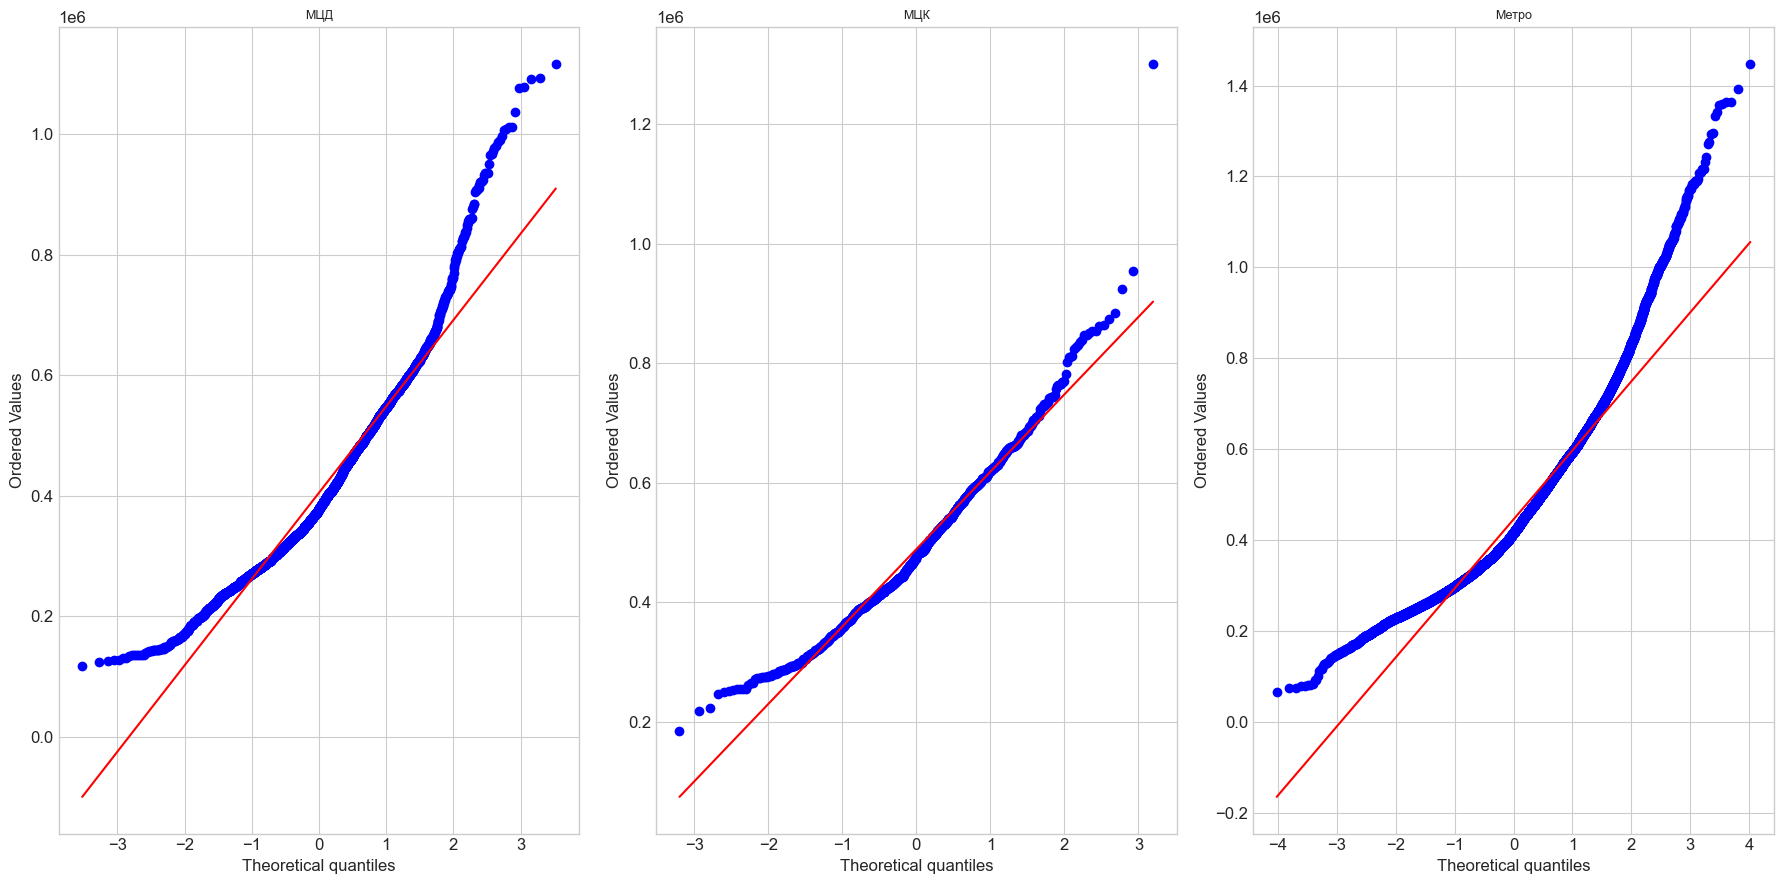

In [157]:
fig, axes = plt.subplots(1, 3, figsize=(18, 9))
axes = axes.flatten()

for i, (name, vals) in enumerate(groups_dict2.items()):
    stats.probplot(vals, plot=axes[i])
    axes[i].set_title(name, fontsize=9)

plt.tight_layout()
plt.show()

Распределения так же отклоняются от нормальных на концах, выберем ANOVA Уэлча как устойчивый к данным параметрам вариант.

Уровень значимости, как на этом тесте, так и на всех последующих выберем 5%

In [158]:
anova_res2 = pg.welch_anova(data=df_work2, dv=TARGET, between=GROUP)

p_col2 = next(c for c in anova_res2.columns if c.startswith('p'))

F_val2 = anova_res2['F'].iloc[0]
p_val2 = anova_res2[p_col2].iloc[0]
eta2_2 = anova_res2['np2'].iloc[0]

print('ANOVA Уэлча, статистики: ')
print(f"F={F_val2}, p={p_val2}, eta2={eta2_2}")
print(f"{'влияет' if p_val2 < 0.05 else 'не влияет'}, объясняет {eta2_2*100:.2f}% дисперсии")

ANOVA Уэлча, статистики: 
F=170.6217413225737, p=6.931110922085827e-70, eta2=0.01005207856605844
влияет, объясняет 1.01% дисперсии


Как и в прошлом варианте, посмотрим постхок - по Геймсу-Ховеллу.

пар всего: 3, значимых: 3
     A      B      diff  pval
2  МЦК  Метро  43627.26   0.0
0  МЦД    МЦК -83722.60   0.0
1  МЦД  Метро -40095.34   0.0


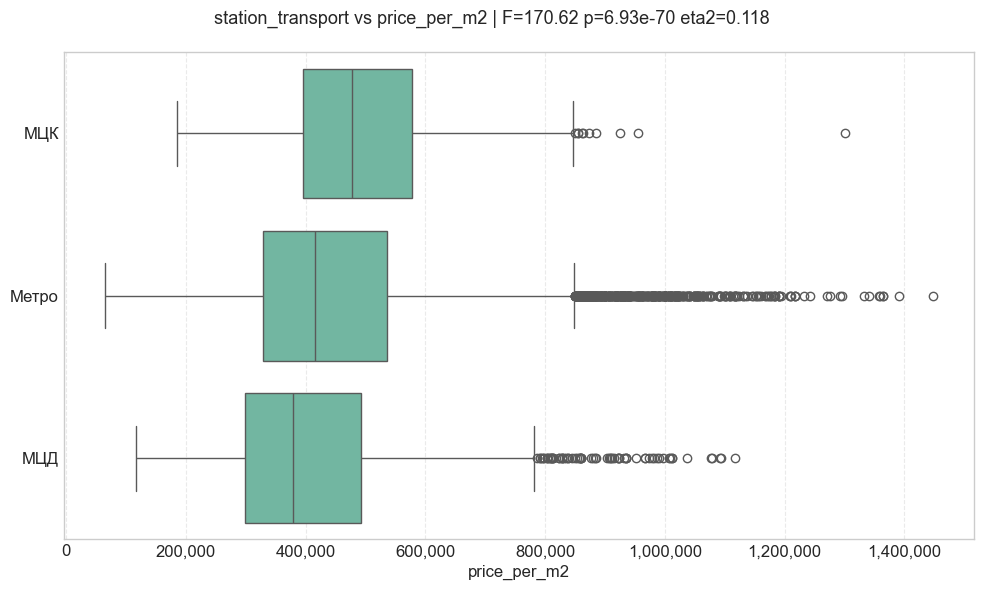

In [159]:
posthoc2 = pg.pairwise_gameshowell(data=df_work2, dv=TARGET, between=GROUP)

means2 = df_work2.groupby(GROUP)[TARGET].mean().to_dict()
posthoc2['mean_A'] = posthoc2['A'].map(means2)
posthoc2['mean_B'] = posthoc2['B'].map(means2)

sig2 = posthoc2[posthoc2['pval'] < 0.05].sort_values('pval')
print(f"пар всего: {len(posthoc2)}, значимых: {len(sig2)}")

print(sig2[['A', 'B', 'diff', 'pval']].round(2))

order2 = df_work2.groupby(GROUP)[TARGET].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"{GROUP} vs {TARGET} | F={F_val2:.2f} p={p_val2:.2e} eta2={eta2:.3f}", fontsize=13)

sns.boxplot(data=df_work2, y=GROUP, x=TARGET, order=order2, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Результаты данного теста снова подтверждают различия между группами. График тоже наглядно демонстрирует сдвиг в ценах от типа к типу.

Проведем тест Краскала-Уоллиса для дополнительной проверки

In [160]:
kw_stat2, kw_p2 = stats.kruskal(*groups_list2)

print(f"H = {kw_stat2:.3f},  p = {kw_p2:.2e}")

H = 353.990,  p = 1.36e-77


Тест Краскала-Уолиса снова показал, что распределения групп не расположены одинаково относительно друг друга.

Посмотрим финальные тесты: попарные Т-тесты с 2 поправками - Бонферрони и BH, которые использовали в предыдущем тесте.

In [161]:
pairs2, pvals_raw2 = [], []
for i, a in enumerate(order2):
    for b in order2[i+1:]:
        t, p = stats.ttest_ind(groups_dict2[a], groups_dict2[b], equal_var=False)
        pairs2.append((a, b))
        pvals_raw2.append(p)

_, pvals_bh2,   _, _ = multipletests(pvals_raw2, method='fdr_bh')
_, pvals_bonf2, _, _ = multipletests(pvals_raw2, method='bonferroni')

ttest_df2 = pd.DataFrame(pairs2, columns=['A', 'B'])
ttest_df2['p_raw']  = pvals_raw2
ttest_df2['p_bh']   = pvals_bh2
ttest_df2['p_bonf'] = pvals_bonf2
ttest_df2['mean_A'] = ttest_df2['A'].map(means2)
ttest_df2['mean_B'] = ttest_df2['B'].map(means2)
ttest_df2['diff']   = ttest_df2['mean_A'] - ttest_df2['mean_B']

sig_ttest2 = ttest_df2[ttest_df2['p_bh'] < 0.05].sort_values('p_bh')

print(f"пар всего: {len(ttest_df2)}")
print(f"значимых BH:         {(ttest_df2['p_bh']   < 0.05).sum()}")
print(f"значимых Бонферрони: {(ttest_df2['p_bonf'] < 0.05).sum()}")
print(f"значимых в GH:       {len(sig2)}")

display(sig_ttest2[['A', 'B', 'mean_A', 'mean_B', 'diff', 'p_raw', 'p_bh', 'p_bonf']].round(2))

пар всего: 3
значимых BH:         3
значимых Бонферрони: 3
значимых в GH:       3


,A,B,mean_A,mean_B,diff,p_raw,p_bh,p_bonf
1,МЦК,МЦД,488813.53,405090.93,83722.60,0.0,0.0,0.0
2,Метро,МЦД,445186.28,405090.93,40095.34,0.0,0.0,0.0
0,МЦК,Метро,488813.53,445186.28,43627.26,0.0,0.0,0.0


Как видим, по Т-тестам независимо от поправки можно заключить, что средние в группах отличаются значимо.

Таким образом, на основе всех тестов, отвергаем H0 и принимаем H1 - стоимость ср. квадратного метра значимо отличается в зависимости от типа транспорта ближайшей станции.

# Алия

## **Проверяемая гипотеза**:
### Средняя стоимость квадратного метра отличается в зависимости от территориального расположения квартиры (Внутри ТТК (вкл. Садовое кольцо) / внутри МКАД / за МКАД)

### **H0**: цена для любых территорий одинаковая, любые наблюдаемые различия случайны

### **H1**: цена статистически значимо отличается хотя бы в одной территориальной зоне. Удаленность от центра влияет на цену


## **Тест на нормальность**:
 Ни одна из изучаемых нами категорий объявлений не распределена нормально (p_value < 0.05):

 1. Внутри Садового кольца и ТТК: p-value = 1.5081e-61
 2. Внутри МКАД: p-value = 1.7873e-196
 3. За МКАД (Область): p-value = 2.8572e-04

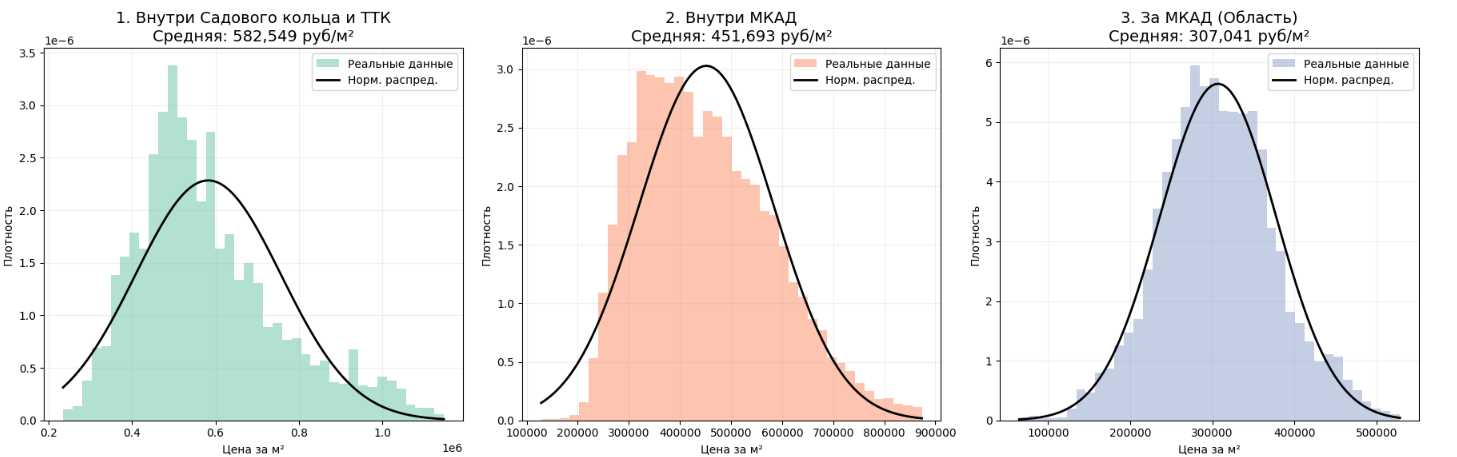

## **Тест Левене** на разброс дисперсий:
Дисперсии значимо отличаются (p_value = 0 < 0.05).
___________
## Поскольку распределения НЕ нормальны (а на таких больших выборках, как у нас, этим можно пренебречь по ЦПТ) и различие дисперсий статистически значимо, основную гипотезу можно проверить с помощью теста ANOVA Уэлча.

## **Тест Welch's ANOVA**:
p_value = 0 => H0 отвергается и цены статистически значимо отличаются для разных локаций.

## Попарные тесты - **критерий Геймса-Хоуэлла**:
В условиях гетероскедатичности и разных объемах сравниваемых выборок в качестве критерия проверки был выбран критерий Геймса-Хоуэлла.

p_value для каждого попарного сравнения групп < 0.05 => цены во всех группах статистически значимо отличаются друг от друга.

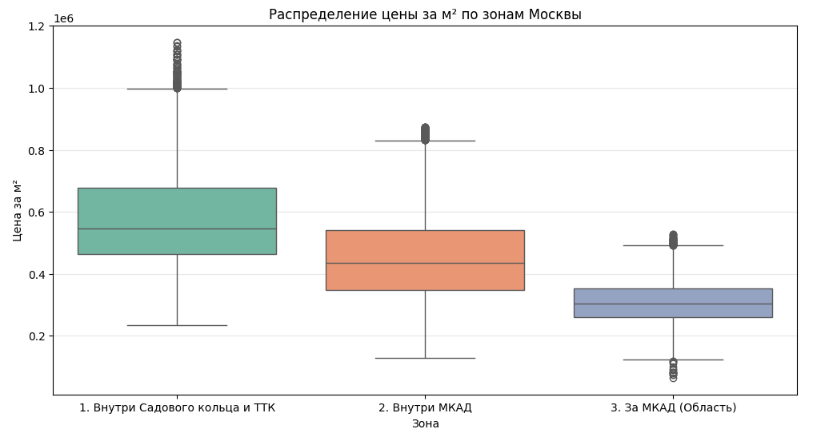

In [162]:
import pingouin as pg

df = pd.read_csv(df_path)
df.head()

,Unnamed: 0,url,address,price,auction,rooms_count,new_building,total_area,living_area,kitchen_area,...,seller_name,fastest_mode,fastest_minutes,nearest_station,stations_nearby,nearest_station_open,nearest_road,distance_from_mkad,roads_nearby_count,distance_from_center
0,0,https://www.cian.ru/sale/flat/324994191/,"москва, юао, р-н даниловский, м. автозаводская...",5350000,н,студия,вторичка,16.0,10.0,5.0,...,NaN,пешком,5.0,автозаводская,3.0,да,NaN,NaN,0.0,5.699610
1,1,https://www.cian.ru/sale/flat/320317503/,"москва, сао, р-н головинский, м. моссельмаш, с...",5990000,н,студия,вторичка,16.0,13.5,5.0,...,NaN,пешком,10.0,моссельмаш,3.0,да,NaN,NaN,0.0,13.636069
2,2,https://www.cian.ru/sale/flat/322151830/,"москва, сао, р-н головинский, м. моссельмаш, с...",5990000,н,студия,вторичка,15.2,12.7,5.0,...,NaN,пешком,10.0,моссельмаш,3.0,да,NaN,NaN,0.0,13.636069
3,6,https://www.cian.ru/sale/flat/324212999/,"москва, вао, р-н измайлово, м. измайловская, 4...",5490000,н,студия,вторичка,31.9,22.9,6.0,...,NaN,пешком,12.0,измайловская,3.0,да,NaN,NaN,0.0,11.640775
4,15,https://www.cian.ru/sale/flat/309052464/,"москва, сао, р-н ховрино, м. грачёвская, фести...",3500000,н,студия,вторичка,10.0,4.0,3.0,...,NaN,пешком,25.0,речной вокзал,3.0,да,NaN,NaN,0.0,14.052945


In [ ]:
# определим зону каждого объявления +
# Очистим от выбросов перед тестоми (по каждой интересующей нас группе) - правило трех сигм

df['price_per_sq_m'] = df['price'] * 1.0 / df['total_area']

ttk_path = 'insert_path'
sadovoye_path = 'insert_path'
mkad_path = 'insert_path'

with open(ttk_path, 'r', encoding='utf-8') as f:
    ttk_data = json.load(f)

with open(sadovoye_path, 'r', encoding='utf-8') as f:
    sad_data = json.load(f)

with open(mkad_path, 'r', encoding='utf-8') as f:
    mkad_data = json.load(f)

#собираем все куски дорог вместе ТТК
ttk_geom = [shape(f['geometry']) for f in ttk_data['features']]
all_ttk = unary_union(ttk_geom)
ttk_polygons = list(polygonize(all_ttk))
ttk_area = max(ttk_polygons, key=lambda p: p.area)

#собираем все куски дорог вместе Садовое
sad_geom = [shape(f['geometry']) for f in sad_data['features']]
all_sad = unary_union(sad_geom)
sad_polygons = list(polygonize(all_sad))
sad_area = max(sad_polygons, key=lambda p: p.area)

#собираем все куски дорог вместе МКАД
mkad_geom = [shape(f['geometry']) for f in mkad_data['features']]
all_mkad = unary_union(mkad_geom)
mkad_polygons = list(polygonize(all_mkad))
mkad_area = max(mkad_polygons, key=lambda p: p.area)

def define_zone_1(row):
    point = Point(row.lng, row.lat)
    if sad_area.contains(point) == True:
        return '1. Садовое кольцо'
    elif ttk_area.contains(point) == True:
        return '2. Внутри ТТК'
    elif mkad_area.contains(point) == True:
        return '3. Внутри МКАД'
    else:
        return '4. За МКАД (Область)'

def define_large_zone(row):
    point = Point(row.lng, row.lat)
    if sad_area.contains(point) == True or ttk_area.contains(point) == True:
        return '1. Внутри Садового кольца и ТТК'
    elif mkad_area.contains(point) == True:
        return '2. Внутри МКАД'
    else:
        return '3. За МКАД (Область)'

#определяем зону
df['zone'] = df.apply(define_zone_1, axis=1)
df['large_zone'] = df.apply(define_large_zone, axis=1)

#удаляем выбросы

zone_stats = df.groupby('large_zone')['price_per_sq_m']
z_scores = (df['price_per_sq_m'] - zone_stats.transform('mean')) / zone_stats.transform('std')


df_corr = df[z_scores <= 3].copy()

print(f"Удалено выбросов: {len(df) - len(df_corr)}")


Удалено выбросов: 225


Поскольку группа данных внутри садового кольца совсем немногочисленная, сразу объединим их вместе с объявлениями внутри ттк (поле large_zone)

In [164]:
df_corr.groupby(df_corr.large_zone, as_index=False).agg({'price_per_sq_m' : 'mean','price' : 'count'})

,large_zone,price_per_sq_m,price
0,1. Внутри Садового кольца и ТТК,582549.040289,2920
1,2. Внутри МКАД,451693.408797,19701
2,3. За МКАД (Область),307041.435491,5339


In [165]:
df_corr.groupby(df_corr.zone, as_index=False).agg({'price_per_sq_m' : 'mean','price' : 'count'})

,zone,price_per_sq_m,price
0,1. Садовое кольцо,711433.417835,108
1,2. Внутри ТТК,577599.000184,2812
2,3. Внутри МКАД,451693.408797,19701
3,4. За МКАД (Область),307041.435491,5339


Проверка на нормальность

In [166]:
group_names = sorted(df_corr['large_zone'].unique())
groups = [df_corr[df_corr['large_zone'] == z]['price_per_sq_m'].dropna() for z in group_names]

#проверка на нормальность
print(" Тест на нормальность")
for name, data in zip(group_names, groups):
    stat, p = stats.normaltest(data)
    print(f"{name}: p-value = {p:.4e} (Нормальное распределение: {p > 0.05})")

# тест Левене
stat_l, p_l = stats.levene(*groups)
print(f"\n Тест Левене")
print(f"Statistic: {stat_l:.4f}")
print(f"p-value: {p_l:.4e}")
print(f"Одинаковые дисперсии: {p_l > 0.05}")

 Тест на нормальность
1. Внутри Садового кольца и ТТК: p-value = 1.5081e-61 (Нормальное распределение: False)
2. Внутри МКАД: p-value = 1.7873e-196 (Нормальное распределение: False)
3. За МКАД (Область): p-value = 2.8572e-04 (Нормальное распределение: False)

 Тест Левене
Statistic: 1207.7163
p-value: 0.0000e+00
Одинаковые дисперсии: False


In [167]:
group_names

['1. Внутри Садового кольца и ТТК', '2. Внутри МКАД', '3. За МКАД (Область)']

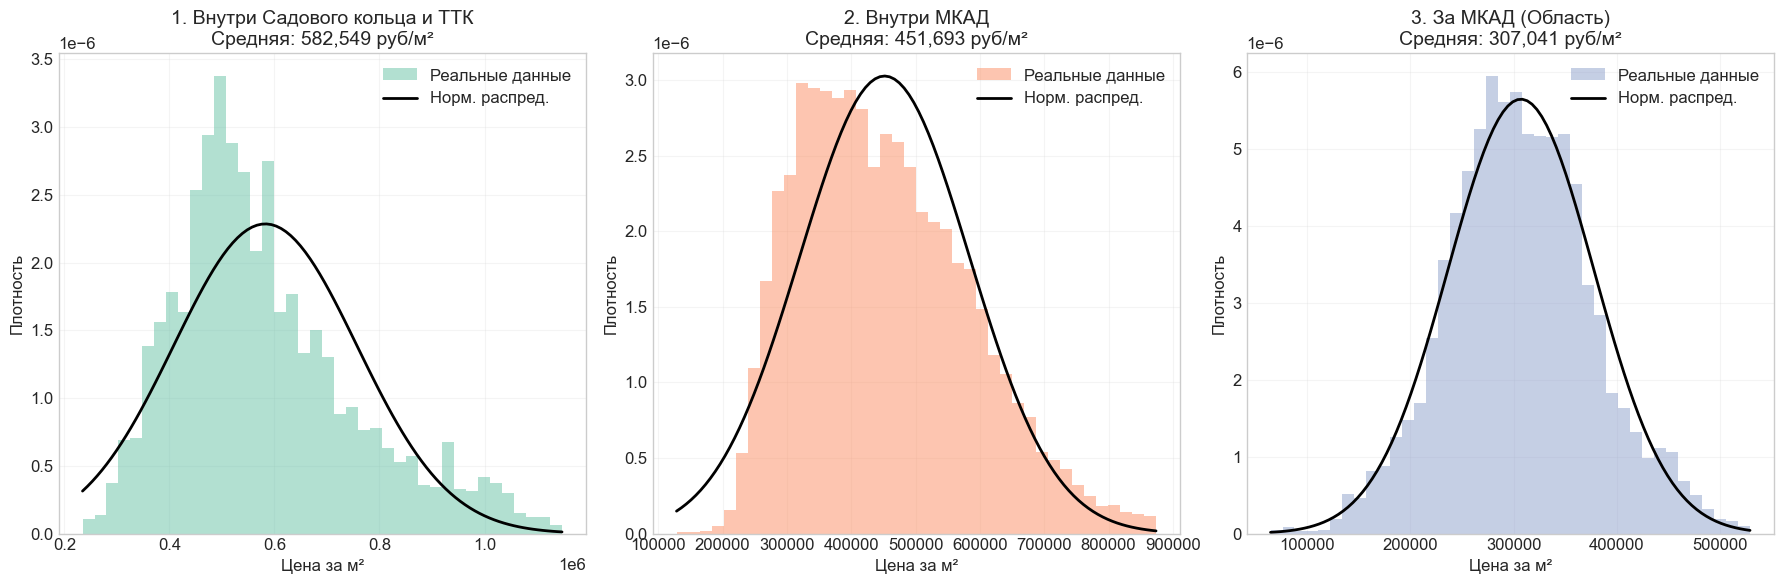

In [168]:
plt.figure(figsize=(18, 6))
colors = plt.cm.Set2.colors


for i, zone in enumerate(group_names):
    data = df_corr[df_corr['large_zone'] == zone]['price_per_sq_m'].dropna()


    mean_raw, std_raw = data.mean(), data.std()
    data_filtered = data#data[np.abs(data - mean_raw) <= 2 * std_raw]

    plt.subplot(1, 3, i+1)

    plt.hist(data_filtered, bins=40, density=True, alpha=0.5, color=colors[i], label='Реальные данные')

    mu, sigma = data_filtered.mean(), data_filtered.std()
    x = np.linspace(data_filtered.min(), data_filtered.max(), 100)
    plt.plot(x, norm.pdf(x, mu, sigma), color='black', lw=2, label='Норм. распред.')

    plt.title(f'{zone}\nСредняя: {int(mu):,} руб/м²', fontsize=14)
    plt.xlabel('Цена за м²')
    plt.ylabel('Плотность')
    plt.legend()
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

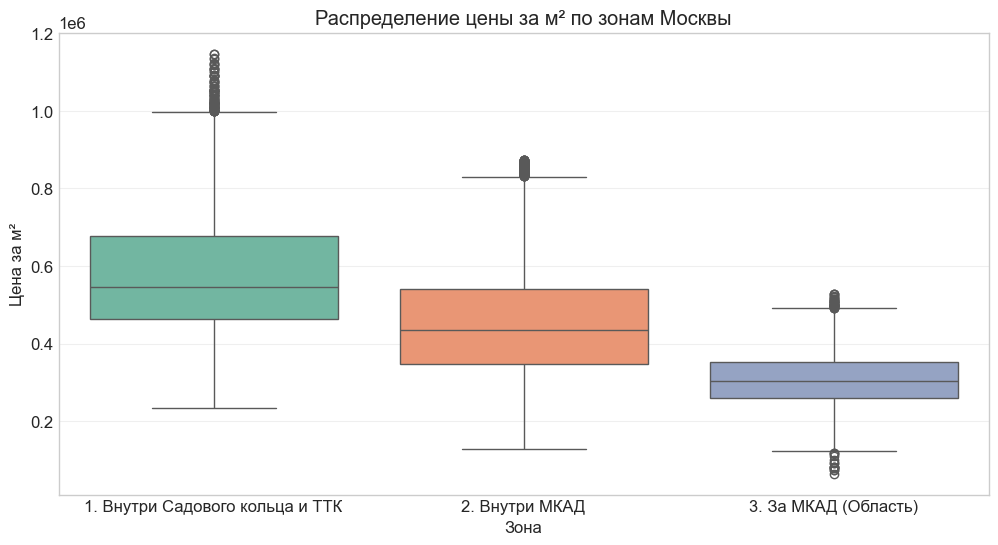


 Тест WELCH'S ANOVA
H0: Цена квартиры за квадратный метр для любой зоны одинаковая, любые наблюдаемые различия случайны
H1: Цена квартиры за квадратный метр статистически значимо отличается хотя бы в одной территориальной зоне. Удаленность от центра влияет на цену

 Результаты теста WELCH'S ANOVA
F-статистика: 7610.89
P-value: 0.0
ВЫВОД: Гипотеза H0 отвергнута. Локация влияет на цену.


In [169]:
zone_order = [
    '1. Садовое кольцо',
    '2. Внутри ТТК',
    '3. Внутри МКАД',
    '4. За МКАД (Область)'
]

large_zone_order = [
    '1. Внутри Садового кольца и ТТК',
    '2. Внутри МКАД',
    '3. За МКАД (Область)'
]

#визуализация
plt.figure(figsize=(12, 6))
sns.boxplot(x='large_zone',
            y='price_per_sq_m',
            data=df_corr,
            palette='Set2',
            order=large_zone_order,
            hue='large_zone',
            legend=False)
plt.title('Распределение цены за м² по зонам Москвы')
plt.xlabel('Зона')
plt.ylabel('Цена за м²')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


print("\n Тест WELCH'S ANOVA")
print("H0: Цена квартиры за квадратный метр для любой зоны одинаковая, любые наблюдаемые различия случайны")
print("H1: Цена квартиры за квадратный метр статистически значимо отличается хотя бы в одной территориальной зоне. Удаленность от центра влияет на цену")

anova_welch = pg.welch_anova(dv='price_per_sq_m', between='large_zone', data=df_corr)

print("\n Результаты теста WELCH'S ANOVA")
print(f"F-статистика: {anova_welch.at[0, 'F']:.2f}")
print(f"P-value: {anova_welch.at[0, 'p_unc']}")



if anova_welch.at[0, 'p_unc'] < 0.05:
    print("ВЫВОД: Гипотеза H0 отвергнута. Локация влияет на цену.")
else:
    print("ВЫВОД: Гипотеза H0 принята. Различий между зонами не найдено.")

## ПОПАРНЫЕ ТЕСТЫ
### В условиях гетероскедатичности и разных объемах сравниваемых выборок в качестве критерия проверки был выбран критерий Геймса-Хоуэлла

In [170]:
pair_compare = pg.pairwise_gameshowell(dv='price_per_sq_m', between='large_zone', data=df_corr)
pair_compare['value_alpha'] = pair_compare['pval'].apply(lambda x: x < 0.05)

print("\n Результаты критерия Геймса-Хоуэлла")
display(pair_compare)


 Результаты критерия Геймса-Хоуэлла


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,value_alpha
0,1. Внутри Садового кольца и ТТК,2. Внутри МКАД,582549.040289,451693.408797,130855.631492,3364.836544,38.889150,3428.624248,2.100431e-12,0.948108,True
1,1. Внутри Садового кольца и ТТК,3. За МКАД (Область),582549.040289,307041.435491,275507.604798,3373.059431,81.678847,3450.742957,0.000000e+00,2.327452,True
2,2. Внутри МКАД,3. За МКАД (Область),451693.408797,307041.435491,144651.973306,1347.952589,107.312360,16217.442334,7.929213e-13,1.192283,True


In [171]:
# # СОХРАНЕНО БЕЗ ВЫВОДА, ОЧЕНЬ МНОГО ПАМЯТИ ЗАНИМАЕТ КАРТА
# #начальные корды
# moscow_coords = [55.7558, 37.6173]
# m = folium.Map(location=moscow_coords, zoom_start=10, tiles='cartodbpositron')

# #все объявления из базы
# df_corr['price_per_sq_m'] = df_corr['price'] * 1.0 / df_corr['total_area']
# bins = df_corr['price_per_sq_m'].quantile([0.2, 0.4, 0.6, 0.8]).values


# #разные цвета - от красного (самое дорогое) до темно зеленого (дешевое)
# def get_color(p, b):
#     if p <= b[0]: return '#006400'
#     if p <= b[1]: return '#90EE90'
#     if p <= b[2]: return '#FFFF00'
#     if p <= b[3]: return '#FFA500'
#     return '#FF0000'

# for _, row in df_corr.iterrows():
#     color = get_color(row['price_per_sq_m'], bins)
#     folium.CircleMarker(
#         location=[row['lat'], row['lng']],
#         radius=4,
#         color=color,
#         weight=0.5,
#         opacity=0.3,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.2,
#         popup=f"{int(row['price_per_sq_m']):,} руб/м²"
#     ).add_to(m)


# #TTK
# with open('ttk.geojson', 'r', encoding='utf-8') as f:
#     ttk_data = json.load(f)

# folium.GeoJson(
#     ttk_data,
#     name='TTK',
#     style_function=lambda x: {
#         'color': 'grey',
#         'weight': 2,
#         'fillOpacity': 0.3
#     }
# ).add_to(m)


# #Садовое
# with open('sadovoye.geojson', 'r', encoding='utf-8') as f:
#     sad_data = json.load(f)

# folium.GeoJson(
#     sad_data,
#     name='Садовое',
#     style_function=lambda x: {
#         'color': 'green',
#         'weight': 2,
#         'fillOpacity': 0.3
#     }
# ).add_to(m)


# #МКАД
# with open('mkad.geojson', 'r', encoding='utf-8') as f:
#     mkad_data = json.load(f)

# folium.GeoJson(
#     mkad_data,
#     name='МКАД',
#     style_function=lambda x: {
#         'color': 'red',
#         'weight': 2,
#         'fillOpacity': 0.3
#     }
# ).add_to(m)



# # Создаем HTML код заголовка
# title_html = '''
#              <h3 align="center" style="font-size:20px"><b>Тепловая карта цен за квадратный метр квартиры в Москве</b></h3>
#              '''

# # Добавляем его на карту
# m.get_root().html.add_child(folium.Element(title_html))

# legend_html = '''
# <div style="
#     position: fixed;
#     bottom: 50px; left: 50px; width: 200px; height: 90px;
#     background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
#     padding: 10px;
#     ">
#     <i style="background: green; width: 15px; height: 3px; display: inline-block"></i>&nbsp; Садовое кольцо <br>
#     <i style="background: grey; width: 15px; height: 3px; display: inline-block"></i>&nbsp; ТТК <br>
#     <i style="background: red; width: 15px; height: 3px; display: inline-block"></i>&nbsp; МКАД
# </div>
# '''

# bins = df_corr['price_per_sq_m'].quantile([0.2, 0.4, 0.6, 0.8]).values
# bins = sorted(list(set(bins)))
# # Define the scale: colors and value range
# # 'RdYlGn_r' is a standard Red-Yellow-Green reversed palette (Green for low, Red for high)
# '''colormap = branca.colormap.LinearColormap(
#     colors=['#006400', '#90EE90', '#FFFF00', '#FFA500', '#FF0000'],
#     index=bins,# dynamic bins
#     vmin=df_corr['price_per_sq_m'].min(),
#     vmax=df_corr['price_per_sq_m'].max(),
#     caption='Price per m²'
# )

# # Usage in the loop:
# color = colormap(row['price_per_sq_m'])

# # Add the colormap legend to the map
# m.add_child(colormap)
# '''
# #m.get_root().html.add_child(folium.Element(legend_html))

# legend_html = f'''
# <div style="
#     position: fixed;
#     top: 10px; right: 10px;
#     width: 180px; z-index: 9999;
#     background-color: rgba(255, 255, 255, 0.9);
#     font-size: 12px; font-family: sans-serif;
#     ">
#     <div style="background-color: white; border:1px solid grey; padding: 10px; border-radius: 5px; margin-bottom: 5px;">
#         <b style="display: block; margin-bottom: 5px;">Цена за м²</b>
#         <div style="line-height: 1.6;">
#             <span style="display: inline-block; width: 15px;"><i style="background: #006400; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> &lt; {int(bins[0]/1000)}к <br>
#             <span style="display: inline-block; width: 15px;"><i style="background: #90EE90; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[0]/1000)}к - {int(bins[1]/1000)}к <br>
#             <span style="display: inline-block; width: 15px;"><i style="background: #FFFF00; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[1]/1000)}к - {int(bins[2]/1000)}к <br>
#             <span style="display: inline-block; width: 15px;"><i style="background: #FFA500; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[2]/1000)}к - {int(bins[3]/1000)}к <br>
#             <span style="display: inline-block; width: 15px;"><i style="background: #FF0000; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> &gt; {int(bins[3]/1000)}к
#         </div>
#     </div>

#     <div style="background-color: white; border:1px solid grey; padding: 10px; border-radius: 5px;">
#         <b style="display: block; margin-bottom: 5px;">Границы</b>
#         <div style="line-height: 1.6;">
#             <span style="display: inline-block; width: 25px;"><i style="background: green; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> Садовое кольцо<br>
#             <span style="display: inline-block; width: 25px;"><i style="background: grey; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> ТТК <br>
#             <span style="display: inline-block; width: 25px;"><i style="background: red; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> МКАД
#         </div>
#     </div>
# </div>
# '''

# m.get_root().html.add_child(folium.Element(legend_html))

# m

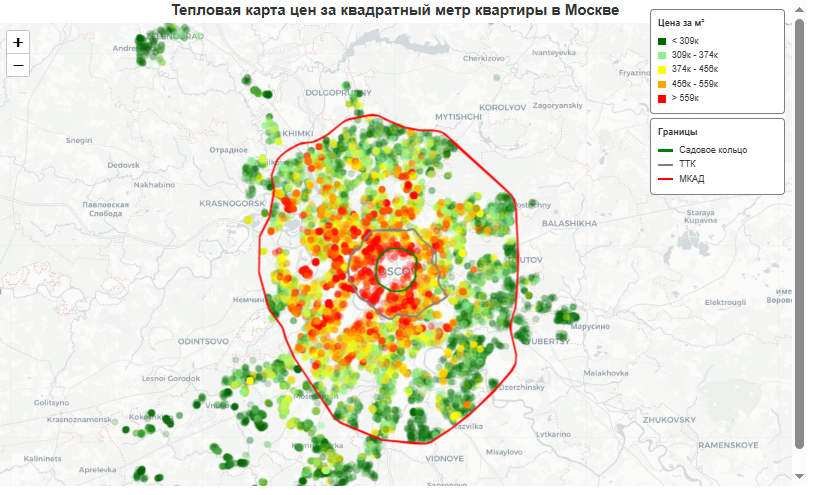

In [172]:
def moscow_base_map(zoom=10):
    #начальные корды
    moscow_coords = [55.7558, 37.6173]
    m = folium.Map(location=moscow_coords, zoom_start=zoom, tiles='cartodbpositron')

    #TTK
    with open(ttk_path, 'r', encoding='utf-8') as f:
        ttk_data = json.load(f)

    folium.GeoJson(
        ttk_data,
        name='TTK',
        style_function=lambda x: {
            'color': 'grey',
            'weight': 2,
            'fillOpacity': 0.3
        }
    ).add_to(m)


    #Садовое
    with open(sadovoye_path, 'r', encoding='utf-8') as f:
        sad_data = json.load(f)

    folium.GeoJson(
        sad_data,
        name='Садовое',
        style_function=lambda x: {
            'color': 'green',
            'weight': 2,
            'fillOpacity': 0.3
        }
    ).add_to(m)


    #МКАД
    with open(mkad_path, 'r', encoding='utf-8') as f:
        mkad_data = json.load(f)

    folium.GeoJson(
        mkad_data,
        name='МКАД',
        style_function=lambda x: {
            'color': 'red',
            'weight': 2,
            'fillOpacity': 0.3
        }
    ).add_to(m)

    return m

map1 = moscow_base_map()
map2 = moscow_base_map()
map3 = moscow_base_map(11)
map4 = moscow_base_map(11)

In [173]:
# # СОХРАНЕНО БЕЗ ВЫВОДА, ОЧЕНЬ МНОГО ПАМЯТИ ЗАНИМАЕТ КАРТА

# fig = branca.element.Figure(width="100%", height="1200px")

# bins = df_corr['price_per_sq_m'].quantile([0.2, 0.4, 0.6, 0.8]).values

# #разные цвета - от красного (самое дорогое) до темно зеленого (дешевое)
# def get_color(p, b):
#     if p <= b[0]: return '#006400'
#     if p <= b[1]: return '#90EE90'
#     if p <= b[2]: return '#FFFF00'
#     if p <= b[3]: return '#FFA500'
#     return '#FF0000'


# #легенда
# legend_html = '''
# <div style="
#     position: absolute;
#     top: 30px; right: 10px; width: 130px; height: 70px;
#     background-color: white; border:2px solid grey; z-index:9999; font-size:11px;
#     padding: 10px;
#     ">
#     <i style="background: green; width: 15px; height: 3px; display: inline-block"></i>&nbsp; Садовое кольцо <br>
#     <i style="background: grey; width: 15px; height: 3px; display: inline-block"></i>&nbsp; ТТК <br>
#     <i style="background: red; width: 15px; height: 3px; display: inline-block"></i>&nbsp; МКАД
# </div>
# '''

# title1 ='''<h3 align="center" style="font-size:14px"><b>За МКАД</b></h3>'''
# title2 ='''<h3 align="center" style="font-size:14px"><b>Внутри МКАД</b></h3>'''
# title3 ='''<h3 align="center" style="font-size:14px"><b>Внутри ТТК</b></h3>'''
# title4 ='''<h3 align="center" style="font-size:14px"><b>Внутри Садового кольца</b></h3>'''



# subplot1 = fig.add_subplot(2, 2, 1)
# subplot2 = fig.add_subplot(2, 2, 2)
# subplot3 = fig.add_subplot(2, 2, 3)
# subplot4 = fig.add_subplot(2, 2, 4)

# # Add separate maps to each subplot
# subplot1.add_child(map1)
# #subplot1.html.add_child(folium.Element(legend_html))
# subplot1.html.add_child(folium.Element(title1))
# for _, row in df_corr[df_corr.zone == '4. За МКАД (Область)'].iterrows():
#     color = get_color(row['price_per_sq_m'], bins)
#     folium.CircleMarker(
#         location=[row['lat'], row['lng']],
#         radius=4,
#         color=color,
#         weight=0.5,
#         opacity=0.3,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.2,
#         popup=f"{int(row['price_per_sq_m']):,} руб/м²"
#     ).add_to(map1)

# subplot2.add_child(map2)
# #subplot2.html.add_child(folium.Element(legend_html))
# subplot2.html.add_child(folium.Element(title2))
# for _, row in df_corr[df_corr.zone == '3. Внутри МКАД'].iterrows():
#     color = get_color(row['price_per_sq_m'], bins)
#     folium.CircleMarker(
#         location=[row['lat'], row['lng']],
#         radius=4,
#         color=color,
#         weight=0.5,
#         opacity=0.3,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.2,
#         popup=f"{int(row['price_per_sq_m']):,} руб/м²"
#     ).add_to(map2)

# subplot3.add_child(map3)
# #subplot3.html.add_child(folium.Element(legend_html))
# subplot3.html.add_child(folium.Element(title3))
# for _, row in df_corr[df_corr.zone == '2. Внутри ТТК'].iterrows():
#     color = get_color(row['price_per_sq_m'], bins)
#     folium.CircleMarker(
#         location=[row['lat'], row['lng']],
#         radius=4,
#         color=color,
#         weight=0.5,
#         opacity=0.3,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.2,
#         popup=f"{int(row['price_per_sq_m']):,} руб/м²"
#     ).add_to(map3)

# subplot4.add_child(map4)
# #subplot4.html.add_child(folium.Element(legend_html))
# subplot4.html.add_child(folium.Element(title4))
# for _, row in df_corr[df_corr.zone == '1. Садовое кольцо'].iterrows():
#     color = get_color(row['price_per_sq_m'], bins)
#     folium.CircleMarker(
#         location=[row['lat'], row['lng']],
#         radius=4,
#         color=color,
#         weight=0.5,
#         opacity=0.3,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.2,
#         popup=f"{int(row['price_per_sq_m']):,} руб/м²"
#     ).add_to(map4)

# legend_html = f'''
# <div style="
#     position: fixed;
#     top: 10px; right: 10px;
#     width: 180px; z-index: 9999;
#     background-color: rgba(255, 255, 255, 0.9);
#     font-size: 12px; font-family: sans-serif;
#     ">
#     <div style="background-color: white; border:1px solid grey; padding: 10px; border-radius: 5px; margin-bottom: 5px;">
#         <b style="display: block; margin-bottom: 5px;">Цена за м²</b>
#         <div style="line-height: 1.6;">
#             <span style="display: inline-block; width: 15px;"><i style="background: #006400; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> &lt; {int(bins[0]/1000)}к <br>
#             <span style="display: inline-block; width: 15px;"><i style="background: #90EE90; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[0]/1000)}к - {int(bins[1]/1000)}к <br>
#             <span style="display: inline-block; width: 15px;"><i style="background: #FFFF00; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[1]/1000)}к - {int(bins[2]/1000)}к <br>
#             <span style="display: inline-block; width: 15px;"><i style="background: #FFA500; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[2]/1000)}к - {int(bins[3]/1000)}к <br>
#             <span style="display: inline-block; width: 15px;"><i style="background: #FF0000; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> &gt; {int(bins[3]/1000)}к
#         </div>
#     </div>

#     <div style="background-color: white; border:1px solid grey; padding: 10px; border-radius: 5px;">
#         <b style="display: block; margin-bottom: 5px;">Границы</b>
#         <div style="line-height: 1.6;">
#             <span style="display: inline-block; width: 25px;"><i style="background: green; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> Садовое кольцо<br>
#             <span style="display: inline-block; width: 25px;"><i style="background: grey; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> ТТК <br>
#             <span style="display: inline-block; width: 25px;"><i style="background: red; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> МКАД
#         </div>
#     </div>
# </div>
# '''

# # Добавляем легенду ОДИН раз на всю фигуру
# fig.html.add_child(folium.Element(legend_html))

# fig

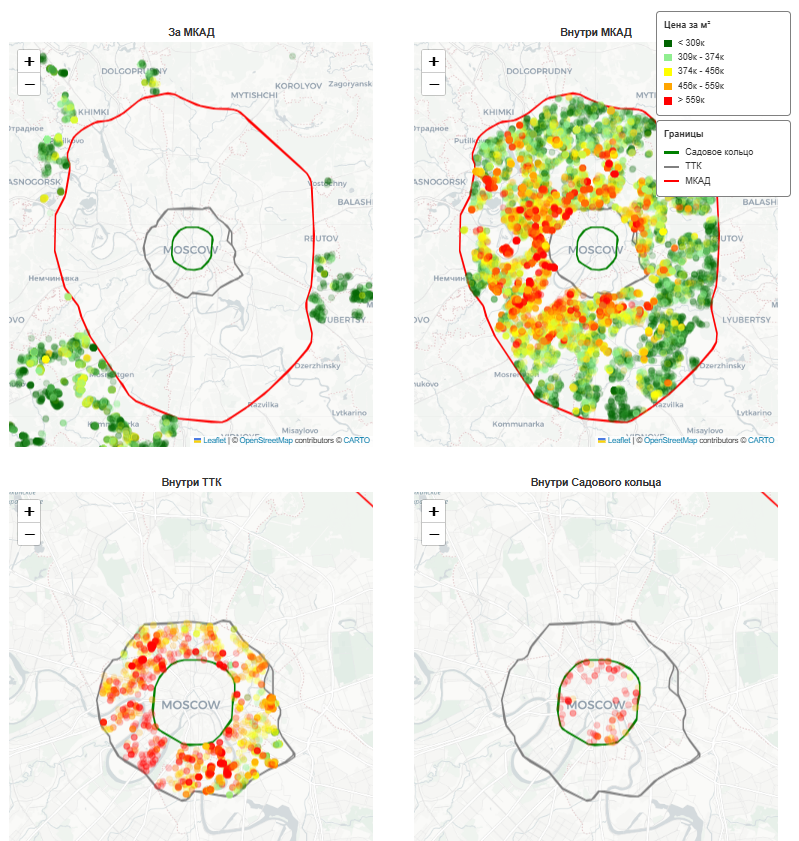

# Настя

In [174]:
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [175]:
df = pd.read_csv(df_path)
df['price_per_m2'] = df['price'] / df['total_area']

### Гипотеза №1: Новостройки vs Вторичка

**Гипотеза**: Средняя цена за 1кв.м. в новостройках выше, чем во вторичном жилье

**H0**: средняя цена новостройки = средняя цена вторички  
**H1**: средняя цена новостройки > средняя цена вторички

In [176]:
new_building_data = df[df['new_building'] == 'новостройка']['price_per_m2']
secondary_data = df[df['new_building'] == 'вторичка']['price_per_m2']

print(f"Новостройки: n={len(new_building_data)}, mean={new_building_data.mean():.0f} руб/м²")
print(f"Вторичка: n={len(secondary_data)}, mean={secondary_data.mean():.0f} руб/м²")
print(f"Разница: {new_building_data.mean() - secondary_data.mean():.0f} руб/м²")

Новостройки: n=9144, mean=495517 руб/м²
Вторичка: n=19041, mean=416208 руб/м²
Разница: 79309 руб/м²


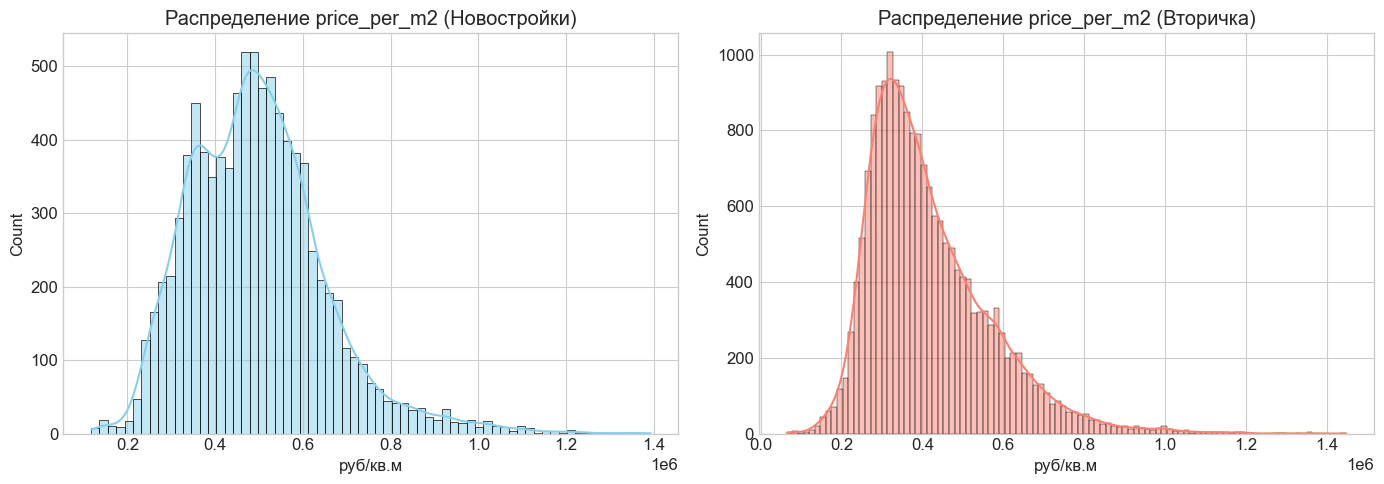

Тест Шапиро-Уилка (Новостройки): p-value = 0.0000
Тест Шапиро-Уилка (Вторичка): p-value = 0.0000
Тест Левена (равенство дисперсий): p-value = 0.0000
Используем equal_var=False



In [177]:
# Нормальность (для больших выборок можно пренебречь, но проверим)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(new_building_data, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение price_per_m2 (Новостройки)')
axes[0].set_xlabel('руб/кв.м')

sns.histplot(secondary_data, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Распределение price_per_m2 (Вторичка)')
axes[1].set_xlabel('руб/кв.м')

plt.tight_layout()
plt.show()

# Тест Шапиро-Уилка (на небольших подвыборках из-за ограничения теста)
shapiro_new = shapiro(new_building_data.sample(min(5000, len(new_building_data)), random_state=42))
shapiro_sec = shapiro(secondary_data.sample(min(5000, len(secondary_data)), random_state=42))

print(f"Тест Шапиро-Уилка (Новостройки): p-value = {shapiro_new[1]:.4f}")
print(f"Тест Шапиро-Уилка (Вторичка): p-value = {shapiro_sec[1]:.4f}")

# Равенство дисперсий (тест Левена)
levene_stat, levene_p = levene(new_building_data, secondary_data)
print(f"Тест Левена (равенство дисперсий): p-value = {levene_p:.4f}")
use_equal_var = levene_p > 0.05
print(f"Используем equal_var={use_equal_var}\n")

Проверка на нормальность (тест Шапиро-Уилка)

- **Новостройки:** p-value < 0.05 -> данные **распределены не нормально**
- **Вторичка:** p-value < 0.05 -> данные **распределены не нормально**

При больших выборках (более 5000 наблюдений) тест на нормальность чувствителен даже к небольшим отклонениям от идеального нормального распределения. Это ожидаемое распределение для наших данных

t-тест является устойчивым к нарушениям нормальности при больших объемах выборок. Благодаря ЦПТ распределение выборочного среднего стремится к нормальному при размере выборки стремящейся к бесконечности. Поэтому мы можем доверять результатам t-теста, несмотря на отклонение от нормальности

---

Проверка на равенство дисперсий (тест Левена)

- **p-value < 0.05** -> дисперсии **статистически значимо различаются**

Разброс цен за квадратный метр в новостройках и вторичке отличается, следовательно, мы не можем предполагать равную дисперсию в двух группах

В связи с неравенством дисперсий будем использовать **t-тест Уэлча** (с параметром `equal_var=False`), который не требует равенства дисперсий и дает более надежные результаты в данной ситуации

In [178]:
# Односторонний t-тест: mean_new > mean_secondary
t_stat, p_value = ttest_ind(new_building_data, secondary_data,
                             equal_var=use_equal_var, alternative='greater')

print(f"t-статистика: {t_stat:.4f}")
print(f"p-value (односторонний): {p_value:.6f}")

if p_value < 0.05:
    print("\nОтвергаем H0")
    print(f"Цена за кв.м в новостройках стат.значимо ВЫШЕ, чем во вторичке")
else:
    print("\nНе отвергаем H0")
    print(f"Нет достаточных доказательств, что цена за кв.м в новостройках стат.значимо выше")

t-статистика: 40.6617
p-value (односторонний): 0.000000

Отвергаем H0
Цена за кв.м в новостройках стат.значимо ВЫШЕ, чем во вторичке


### Результаты проверки гипотезы №1: Новостройки vs Вторичка

---
### Проверяемая гипотеза
**Гипотеза**: Средняя цена за 1кв.м. в новостройках выше, чем во вторичном жилье

**H0**: средняя цена новостройки = средняя цена вторички  
**H1**: средняя цена новостройки > средняя цена вторички

---
### Статистический тест
Для проверки гипотезы использовался **односторонний t-тест для НЕЗАВИСИМЫХ выборок** (t-тест Уэлча), так как:
- Сравниваются средние значения количественного признака (price_per_m2) в двух независимых группах
- Тест Левена показал неравенство дисперсий (p-value < 0.05), поэтому использована поправка на неравные дисперсии
- Выборки имеют большой объем (> 5000 наблюдений), что делает t-тест устойчивым к нарушению нормальности

---
### Результаты теста
- **t-статистика = 40.6617**
- **p-value (односторонний) = 0.000000**
- **Уровень значимости α = 0.05**
- **Средняя цена за кв.м в новостройках: 495 517 руб/кв.м**
- **Средняя цена за кв.м во вторичке: 416 208 руб/кв.м**
- **Разница: 79 309 руб/кв.м (новостройки дороже)**

---
### Вывод

**Нулевая гипотеза (H0) ОТВЕРГАЕТСЯ**

**p-value (0.000000) < α (0.05)**

Цена за кв.м в новостройках стат.значимо ВЫШЕ, чем во вторичке

Новостройки имеют более высокую стоимость кв.м по сравнению со вторичным жильем, что соответствует рыночной логике и подтверждает выдвинутую гипотезу

### Гипотеза №2: Цена за кв.м от типа дома

**Гипотеза**: ср.цена за 1 кв.м в домах разного типа (монолт, кирпич, панелька и т.д.) различается

**H0**: ср.цена за 1 кв.м одинаковая во всех домах разного типа  
**Н1**: ср.цена за 1 кв.м в доме хотя бы одного типа стат.значимо отличается

In [179]:
# Очищаем и фильтруем типы домов
valid_house_types = ['блочный', 'кирпичный', 'монолитный', 'панельный', 'монолитно-кирпичный']
df_house = df[df['house_type'].isin(valid_house_types)].copy()

# Группируем данные для ANOVA
groups = [df_house[df_house['house_type'] == htype]['price_per_m2'].values for htype in valid_house_types]
group_names = valid_house_types
group_sizes = [len(g) for g in groups]
group_means = [g.mean() for g in groups]

print("\nСтатистика по группам:")
for name, size, mean in zip(group_names, group_sizes, group_means):
    print(f"  {name:20} | n={size:5} | mean={mean:.0f} руб/м²")


Статистика по группам:
  блочный              | n= 1037 | mean=367000 руб/м²
  кирпичный            | n= 2815 | mean=406907 руб/м²
  монолитный           | n=17473 | mean=477077 руб/м²
  панельный            | n= 4717 | mean=326587 руб/м²
  монолитно-кирпичный  | n= 2143 | mean=491613 руб/м²


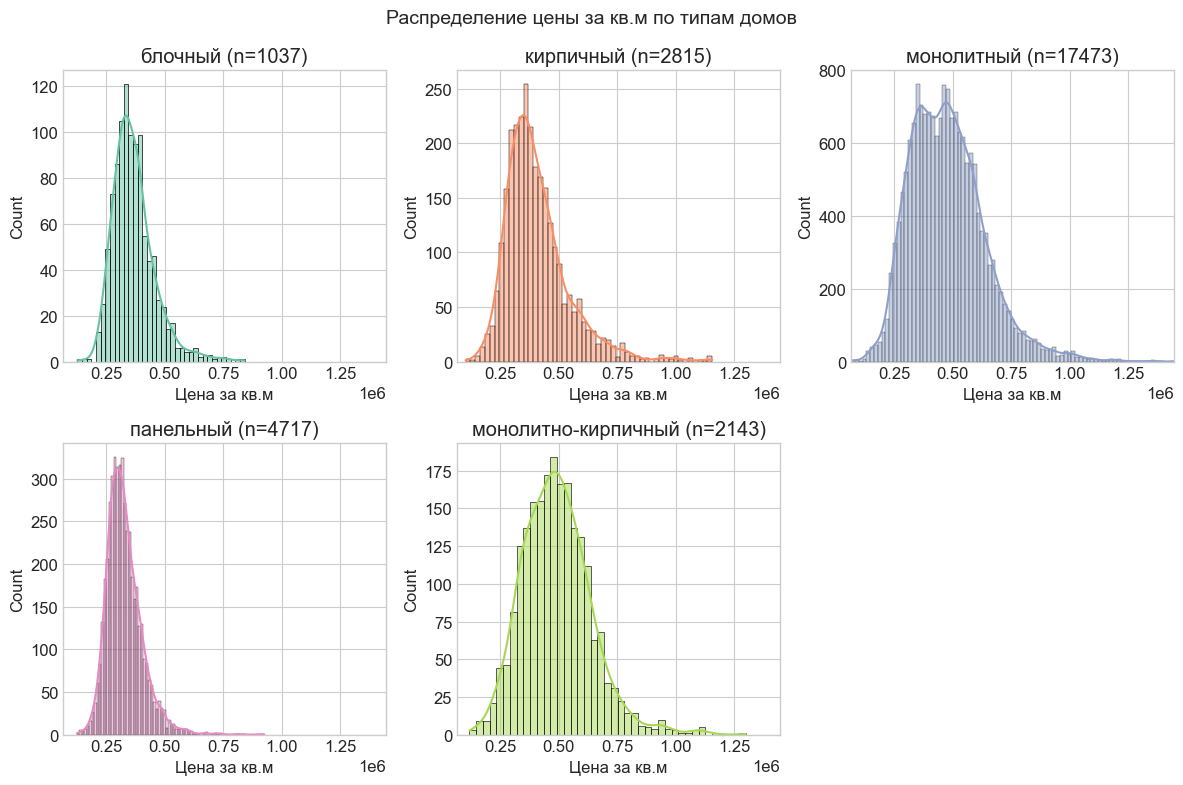

Тест Шапиро-Уилка
   блочный              | p-value = 0.000000 | данные распределены НЕ нормально
   кирпичный            | p-value = 0.000000 | данные распределены НЕ нормально
   монолитный           | p-value = 0.000000 | данные распределены НЕ нормально
   панельный            | p-value = 0.000000 | данные распределены НЕ нормально
   монолитно-кирпичный  | p-value = 0.000000 | данные распределены НЕ нормально


In [180]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Находим общие границы для всех графиков, чтоб ось X привести к одному масштабу
x_min = min([g.min() for g in groups])
x_max = max([g.max() for g in groups])

for i, (name, group) in enumerate(zip(group_names, groups)):
    sns.histplot(group, kde=True, ax=axes[i], color=sns.color_palette()[i])
    axes[i].set_title(f'{name} (n={len(group)})')
    axes[i].set_xlabel('Цена за кв.м')
    axes[i].set_xlim(x_min, x_max)

for j in range(len(group_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределение цены за кв.м по типам домов', fontsize=14)
plt.tight_layout()
plt.show()

shapiro_results = []
print(f"Тест Шапиро-Уилка")
for name, group in zip(group_names, groups):
    sample_size = min(5000, len(group))
    sample_data = np.random.choice(group, sample_size, replace=False) if len(group) > 5000 else group
    shapiro_stat, shapiro_p = shapiro(sample_data)
    shapiro_results.append((name, shapiro_p))
    normal_status = "НЕ нормально" if shapiro_p < 0.05 else "нормально"
    print(f"   {name:20} | p-value = {shapiro_p:.6f} | данные распределены {normal_status}")

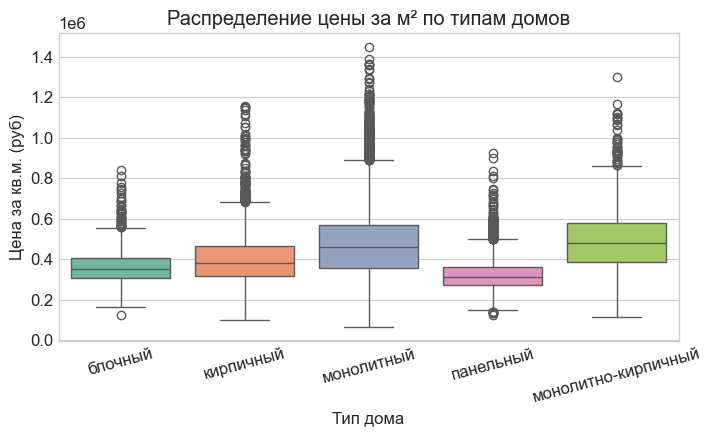

Тест Левена (равенство дисперсий): p-value = 0.0000
Дисперсии значимо различаются


In [181]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_house, x='house_type', y='price_per_m2',
            order=valid_house_types, palette='Set2')
plt.title('Распределение цены за м² по типам домов')
plt.xlabel('Тип дома')
plt.ylabel('Цена за кв.м. (руб)')
plt.xticks(rotation=15)
plt.show()

levene_stat, levene_p = levene(*groups)
print(f"Тест Левена (равенство дисперсий): p-value = {levene_p:.4f}")
print(f"{'Дисперсии можно считать равными' if levene_p > 0.05 else 'Дисперсии значимо различаются'}")

Тест Шапиро-Уилка

**Во всех пяти группах распределение цены за кв.метр стат.значимо отличается от нормального.** Ожидаемо для данных о ценах на недвижимость, они обычно имеют правостороннюю асимметрию и «тяжелые хвосты»

ANOVA является устойчивым к нарушениям нормальности при больших объемах выборок. Во всех пяти группах количество наблюдений значительно превышает 30

Благодаря ЦПТ, распределение выборочных средних стремится к нормальному при увеличении размера выборки. Поэтому мы можем доверять результатам ANOVA, несмотря на отклонение от нормальности в исходных данных

---

тест Левена

- **p-value < 0.05** -> дисперсии **статистически значимо различаются**

Разброс цен за кв.метр отличается в разных типах домов. При чем разброс цен в зависимости от типа дома сильно отличается
  
Поскольку классическая ANOVA чувствительна к сильному неравенству дисперсий при не равном размерове групп, для подтверждения надежности проведем дополнительную проверку с помощью **критерия Уэлча (Welch's ANOVA)**. Этот метод не требует равенства дисперсий и является более робастным в данных условиях

---

Несмотря на то, что предпосылки ANOVA (нормальность и равенство дисперсий) не выполняются, мы будем использовать ANOVA по следующим причинам:

 1. **Устойчивость к ненормальности:** Благодаря очень большим объемам выборок (все n > 1000), выборочные средние распределены нормально, что позволяет использовать параметрические методы
 2. **Доп.проверка на неравенство дисперсий:** дополнительно проведем **Welch's ANOVA**, который специально разработан для случаев с неравными дисперсиями и разными размерами выборок
 3. **Тест Геймса-Хоуэлла для попарного сравнения:** Для попарных сравнений будет использован  **критерий Геймса-Хоуэлла**. Он не требует равенства дисперсий

Таким образом, результаты ANOVA и последующих попарных сравнений будут статистически обоснованными и надежными

In [182]:
f_stat, p_value = f_oneway(*groups)

print(f"ANOVA classic")
print(f"F-статистика: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nОтвергаем H0")
    print("Есть статистически значимые различия в цене за кв.м между типами домов")
    print("Переходим к тесту Welch's ANOVA")
else:
    print("\nНе отвергаем H0")
    print("Нет достаточных доказательств различий между типами домов")
    print("Переходим к тесту Welch's ANOVA")

ANOVA classic
F-статистика: 1191.9374
p-value: 0.000000

Отвергаем H0
Есть статистически значимые различия в цене за кв.м между типами домов
Переходим к тесту Welch's ANOVA


In [183]:
welch_anova = pg.welch_anova(data=df, dv='price_per_m2', between='house_type')

print(f"Welch's ANOVA")
print(f"F-статистика: {welch_anova['F'].values[0]:.4f}")
print(f"p-value: {welch_anova['p_unc'].values[0]:.4f}")

p_val_welch = welch_anova['p_unc'].values[0]

if p_val_welch < 0.05:
    print("\nОтвергаем H0")
    print("Есть статистически значимые различия в цене за кв.м между типами домов")
else:
    print("\nНе отвергаем H0")
    print("Нет достаточных доказательств различий между типами домов")

Welch's ANOVA
F-статистика: 2348.3778
p-value: 0.0000

Отвергаем H0
Есть статистически значимые различия в цене за кв.м между типами домов


In [184]:
post_hoc = pg.pairwise_gameshowell(data=df, dv='price_per_m2', between='house_type')

print("\nРезультаты попарных сравнений (Games-Howell):")
print(post_hoc[['A', 'B', 'mean_A', 'mean_B', 'diff', 'pval']])


Результаты попарных сравнений (Games-Howell):
                     A                    B         mean_A         mean_B  \
0              блочный            кирпичный  367000.400179  406906.533189   
1              блочный  монолитно-кирпичный  367000.400179  491612.639096   
2              блочный           монолитный  367000.400179  477076.892950   
3              блочный            панельный  367000.400179  326586.979164   
4            кирпичный  монолитно-кирпичный  406906.533189  491612.639096   
5            кирпичный           монолитный  406906.533189  477076.892950   
6            кирпичный            панельный  406906.533189  326586.979164   
7  монолитно-кирпичный           монолитный  491612.639096  477076.892950   
8  монолитно-кирпичный            панельный  491612.639096  326586.979164   
9           монолитный            панельный  477076.892950  326586.979164   

            diff          pval  
0  -39906.133010  1.981082e-12  
1 -124612.238916  1.601941e-12  
2 -110

### Результаты проверки гипотезы №2: Тип дома и цена за кв.метр

---
### Проверяемая гипотеза
**Гипотеза**: Средняя цена за квадратный метр различается в зависимости от типа дома

**H0**: средняя цена за кв.м одинакова во всех типах домов  
**H1**: средняя цена за кв.м различается в зависимости от типа дома

---
### Статистический тест

**F-статистика Уэлча (2348)** почти в два раза выше, чем у обычной ANOVA (1191). Это говорит, что обычная ANOVA недооценивала различия из-за разницы в дисперсиях
  
Для проверки гипотезы использовался комплексный подход для наших данных:
 1. **Welch's ANOVA** - основной тест для сравнения средних. Выбран вместо классической ANOVA, так как тест Левена подтвердил неравенство дисперсий, а размеры групп сильно различаются
 2. **Попарный анализ Games-Howell** - использован для попарных сравнений. Этот критерий является наиболее оптимальным в условиях сильно вириативной дисперси и больших выборок разного размера
 3. **Обоснование выбора параметрических критериев**: Несмотря на ненормальное распределение, объемы выборок в каждой группе позволяют опираться на ЦПТ

---
### Результаты теста

**Welch's ANOVA:**
 * **F-статистика = 2348.3778**
 * **p-value = 0.0000** (статистически значимо)
 * **Уровень значимости $\alpha$ = 0.05**

**Попарные сравнения (Games-Howell):**
Все 10 пар сравнения показали высокую статистическую значимость (**pval < 0.05**). Это означает, что цена за квадратный метр в каждом типе дома уникальна и значимо отличается от всех остальных

---
### Вывод

**Нулевая гипотеза (H0) ОТВЕРГАЕТСЯ**  
Значение p-value теста Уэлча и всех попарных сравнений Геймса-Хоуэлла составляет менее 0.001. Тип дома оказывает существенное влияние на стоимость квадратного метра

# Кирилл

**Проверяемая гипотеза:** Средняя цена за кв.м. зависит от количества станций метро поблизости к дому

**H0:** Квартиры с тремя по близости станциями метро имеют примерно ту же среднюю стоимость за кв.м.,  что и квартиры с менее  чем 3 станций метро

**H1:** Квартиры с тремя по близости станциями метро имеют отличную среднюю стоимость за кв.м. от квартир с менее  чем 3 станций метро

В качестве статистического критерия выбрал `t-тест`, потому что:

*   Проверяю две независимые группы (выборки) на равенство средних
*   T-тест имеет поправку Уэлча, которая позволяет производить более точные вычисления при неравенстве дисперсий





Результаты t-теста:
*  `t_stat = 49`
*   `p-value = 0`
* Уровень значимости `α = 0.05`


Визуализация средних цен за кв.м. по группам:

* Группа (0-2) - от ни одной до двух станций метро вблизи квартиры
* Группа (3) - ровно три станции метро по близости

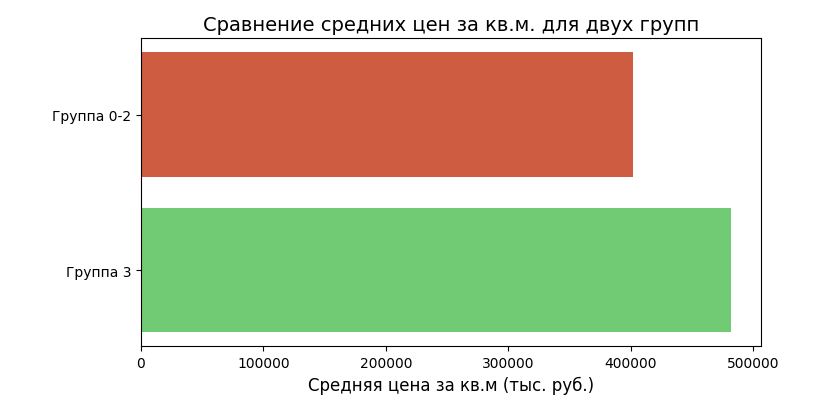

ВЫВОД

**НУЛЕВАЯ ГИПОТЕЗА ОТКЛОНЯЕТСЯ**, так как:
*   `t_stat > |3|` означает, что различия в средней цене за квадратный метр для квартир с тремя станциями метро по близости и с менее тремя станциями статистически различимо.
*   Значение `p-value` в районе нуля означает, что вероятность случайно получить различия в цене практически невозможно.





In [185]:
df = pd.read_csv(df_path)

In [186]:
hdf = df[['price','stations_nearby','total_area']].copy()
hdf['price_per_m2'] = hdf['price'] / hdf['total_area']  # новая фича - цена за кв.м
hdf['is_three_st_nearby'] = hdf['stations_nearby'] == 3 # новая фича - True для 3-х станций по близости, иначе (0-2) --> False

In [187]:
group_eq_three = hdf[hdf['is_three_st_nearby'] == True]['price_per_m2']
group_less_than_three = hdf[hdf['is_three_st_nearby'] == False]['price_per_m2']

#group_less_than_three = hdf_not_true_only['price_per_m2']
#group_eq_three = hdf_true_only['price_per_m2']

print(f"Размеры выборок для групп:\nГруппа (0-2): {group_less_than_three.shape[0]} записей\nГруппа (3): {group_eq_three.shape[0]} записей")

Размеры выборок для групп:
Группа (0-2): 9281 записей
Группа (3): 18904 записей


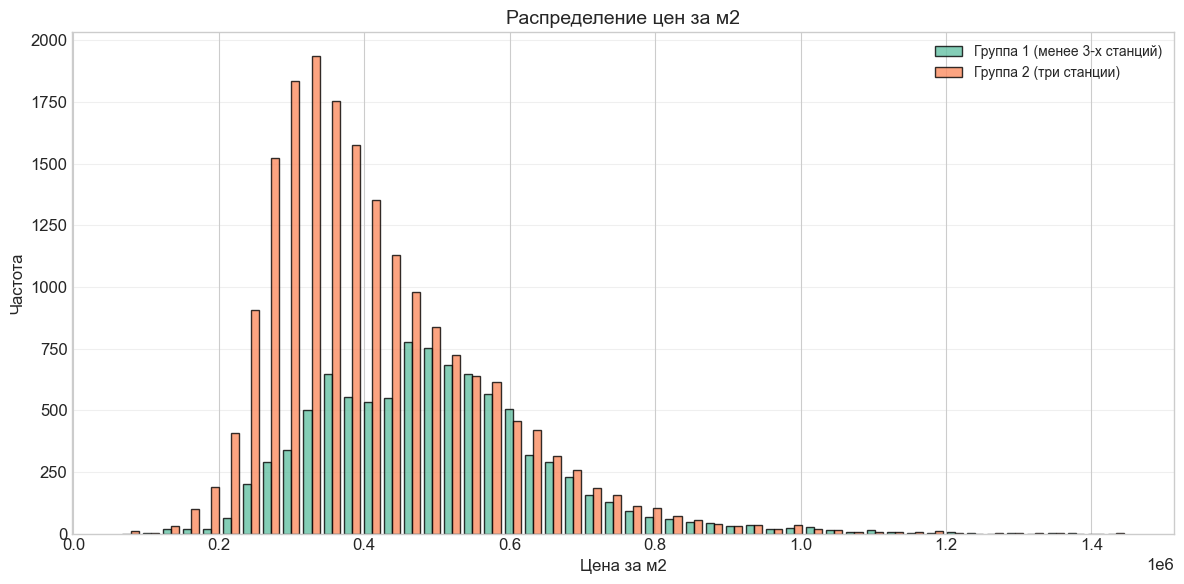

In [188]:
import seaborn as sns
sns.set_palette("Set2")

plt.figure(figsize=(12, 6))

bins = np.histogram_bin_edges(
    np.concatenate([group_less_than_three, group_eq_three]),
    bins=50
)

plt.hist([group_less_than_three, group_eq_three],
         bins=bins,
         edgecolor='black',
         alpha=0.8,
         label=['Группа 1 (менее 3-х станций)', 'Группа 2 (три станции)'],
         histtype='bar',
         rwidth=0.8)

plt.title('Распределение цен за м2', fontsize = 14)
plt.xlabel('Цена за м2', fontsize = 12)
plt.ylabel('Частота', fontsize = 12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Проверим на соответствие распределений в группах нормальному при помощи теста Колмогорова-Смирнова

In [189]:
from scipy.stats import kstest, norm

def normalize(df):
  """
  Функция для нормализации цен в датасете
  """

  data = df.copy()
  normalized_data = ((data - data.mean()) / data.std())

  return normalized_data

group_less_than_three_normalized = normalize(group_less_than_three)
group_eq_three_normalized = normalize(group_eq_three)

dstat_less_than_three, p_value_less_than_three = kstest(group_less_than_three_normalized,'norm')
dstat_eq_three, p_value_eq_three = kstest(group_eq_three_normalized,'norm')

report = f"""Результаты теста Колмогорова-Смирнова на нормальность распределения данных в группах.

Для группы 0-2 станции метро по близости к дому:
- Значение p-value : {p_value_less_than_three},
- Значение D-статистики: {dstat_less_than_three:.4f}

Для группы 3 станции метро по близости к дому:
- Значение p-value: {p_value_eq_three}
- Значение D-статистики: {dstat_eq_three:.4f}"""

print(report)

Результаты теста Колмогорова-Смирнова на нормальность распределения данных в группах.

Для группы 0-2 станции метро по близости к дому:
- Значение p-value : 4.185046102847456e-15,
- Значение D-статистики: 0.0426

Для группы 3 станции метро по близости к дому:
- Значение p-value: 6.050383397635288e-158
- Значение D-статистики: 0.0978


**Интерпретация** теста Колмогорова-Смирнова: нулевая гипотеза о том, что данные подвергаются **нормальному закону распределения** для двух групп **отклоняется**, так как значение `p-value ≈ 0`

Также, значение `D-стат. = 0.04` для группы (0-2) говорит о наблюдаемых отклонений от нормального закона распределения. Для группы (3) это отклонение ещё сильнее.

Построим боксплоты для распределения средних цен за кв.м. для групп

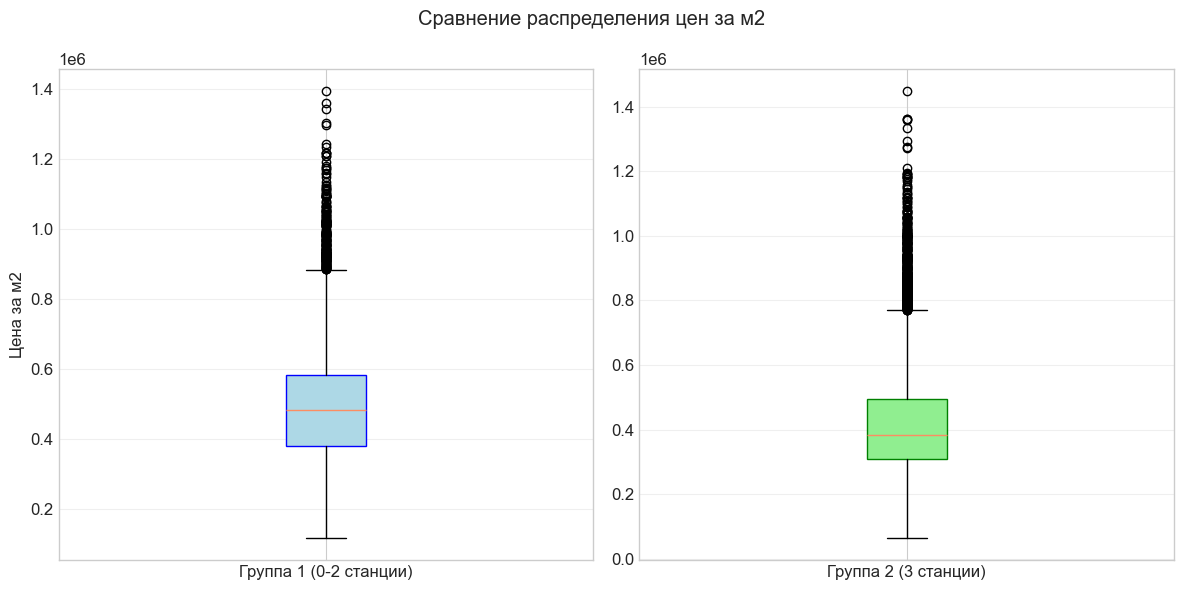

In [190]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(group_less_than_three, labels=['Группа 1 (0-2 станции)'],
            patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'))
ax2.boxplot(group_eq_three, labels=['Группа 2 (3 станции)'],
            patch_artist=True, boxprops=dict(facecolor='lightgreen', color='green'))

ax1.set_ylabel('Цена за м2')
ax1.grid(axis='y', alpha=0.3)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение распределения цен за м2')
plt.tight_layout()
plt.show()

Как можно заметить по графикам - наблюдаются выбросы по цене для каждой из групп, которые необходимо обработать для корректного использования статистического критерия, который чувствителен к этим выбросам.

Для обработки я воспользуюсь методом IQR и срезом через 1 и 99 процентиль

In [191]:
def processing_outliers_iqr(df):
    """Обработка выбросов по IQR"""

    data = df.copy()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - IQR * 1.5
    upper_bound = Q3 + IQR * 1.5

    non_outliers_mask = (data >= lower_bound) & (data <= upper_bound)

    data_wo_outliers = data[non_outliers_mask]

    return data_wo_outliers

def processing_outliers_percentile(df, lower_percentile : int = 1, upper_percentile : int = 99):
    """Обработка выбросов по заданном процентилям нижней и верхней границы"""

    data = df.copy()
    lower_bound = data.quantile(lower_percentile / 100)
    upper_bound = data.quantile(upper_percentile / 100)

    data_wo_outliers = data[(data >= lower_bound) & (data <= upper_bound)]

    return data_wo_outliers

iqr_df_less_than_three = processing_outliers_iqr(group_less_than_three)
iqr_df_eq_three = processing_outliers_iqr(group_eq_three)

percentile_df_less_than_three = processing_outliers_percentile(iqr_df_less_than_three)
percentile_df_eq_three = processing_outliers_percentile(iqr_df_eq_three)

report = f"""Выборка до/после обработки выбросов (группа 0-2) из {group_less_than_three.shape[0]}/{percentile_df_less_than_three.shape[0]} записей
Процент затёртых данных: {((1 - (percentile_df_less_than_three.shape[0]/ group_less_than_three.shape[0])))*100:.1f}%

Выборка до/после обработки выбросов обработки (группа 3) из {group_eq_three.shape[0]}/{percentile_df_eq_three.shape[0]} записей
Процент затёртых данных: {((1 - (percentile_df_eq_three.shape[0]/ group_eq_three.shape[0])))*100:.1f}%
"""

print(report)

Выборка до/после обработки выбросов (группа 0-2) из 9281/8895 записей
Процент затёртых данных: 4.2%

Выборка до/после обработки выбросов обработки (группа 3) из 18904/18030 записей
Процент затёртых данных: 4.6%



После обработки выбросов `по IQR совместно и срезом по 1 и 99 процентилем` - визуализируем боксплоты распределения средних цен за кв.м.

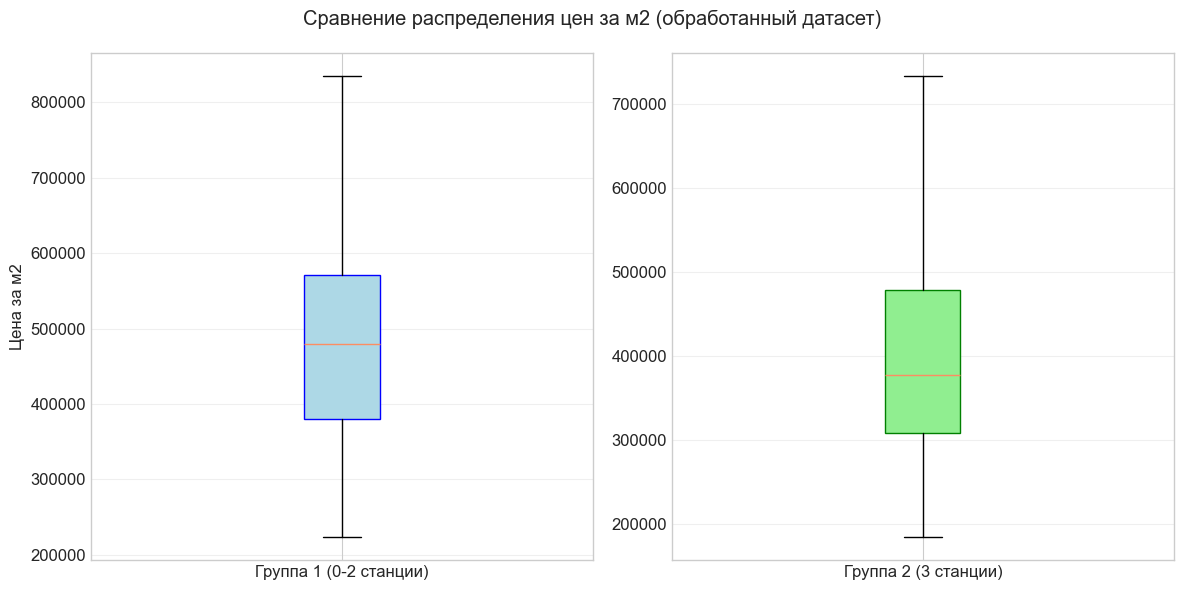

In [192]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(percentile_df_less_than_three, labels=['Группа 1 (0-2 станции)'],
            patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'))
ax2.boxplot(percentile_df_eq_three, labels=['Группа 2 (3 станции)'],
            patch_artist=True, boxprops=dict(facecolor='lightgreen', color='green'))

ax1.set_ylabel('Цена за м2')
ax1.grid(axis='y', alpha=0.3)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение распределения цен за м2 (обработанный датасет)')
plt.tight_layout()
plt.show()

После того, как выбросы обработаны - можно приступать к использованию `t-теста`.

Но перед этим проиллюстрирую средние цены за кв.м. для каждой из группы

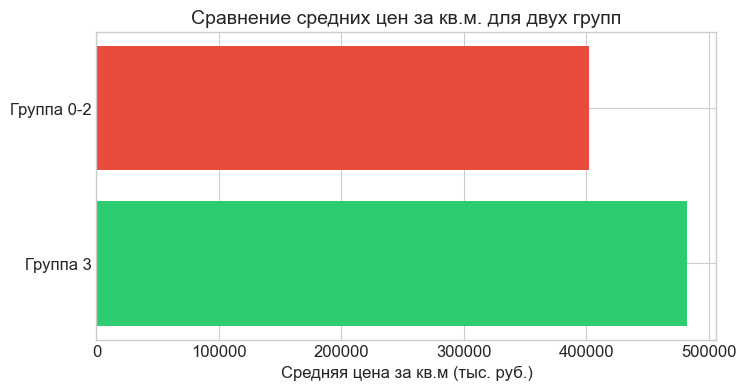

In [193]:
price_per_m2_3 = percentile_df_less_than_three.mean()
price_per_m2_0_2 = percentile_df_eq_three.mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(['Группа 3','Группа 0-2'],
               [price_per_m2_3, price_per_m2_0_2],
               color=['#2ecc71', '#e74c3c'])

plt.title('Сравнение средних цен за кв.м. для двух групп', fontsize = 14)
plt.xlabel('Средняя цена за кв.м (тыс. руб.)', fontsize = 12)
plt.show()

Невооружённым глазом можно заметить, что разница средних за квадратный метр для двух групп присутствует.

Проверить, является ли статистически значимой разница средних поможет `t-тест` с поправкой Уэлча (`equal_var = False`).

In [194]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(percentile_df_less_than_three, percentile_df_eq_three, equal_var=False)
print(f"Значение t_stat: {t_stat:.4f} и p-value: {p_value:.5f}")

Значение t_stat: 49.0356 и p-value: 0.00000


**ИНТЕРПРЕТАЦИЯ**:
*   `t_stat > |3|` означает, что различия в средней цене за квадратный метр для квартир с тремя станциями метро по близости и с менее тремя станциями статистически различимо.
*   Значение `p-value` в районе нуля означает, что вероятность случайно получить различия в цене практически невозможно.

**НУЛЕВАЯ ГИПОТЕЗА ОТКЛОНЯЕТСЯ**

# Никита

**Гипотеза:**  
Цена за кв.м. зависит от высоты потолков. Смотрим на условные группы по "комфортности". Здесь буду считать базовой высоту до 2.8, комфорт - до 3.0, бизнес - выше 3.0  

**H0:** Средняя цена за кв.м. не отличается между группами  
**H1:** Средняя цена отличается хотя бы у одной пары групп

In [195]:
df = pd.read_csv(df_path)
df_hyp = df.copy()
df_hyp.head()

,Unnamed: 0,url,address,price,auction,rooms_count,new_building,total_area,living_area,kitchen_area,...,seller_name,fastest_mode,fastest_minutes,nearest_station,stations_nearby,nearest_station_open,nearest_road,distance_from_mkad,roads_nearby_count,distance_from_center
0,0,https://www.cian.ru/sale/flat/324994191/,"москва, юао, р-н даниловский, м. автозаводская...",5350000,н,студия,вторичка,16.0,10.0,5.0,...,NaN,пешком,5.0,автозаводская,3.0,да,NaN,NaN,0.0,5.699610
1,1,https://www.cian.ru/sale/flat/320317503/,"москва, сао, р-н головинский, м. моссельмаш, с...",5990000,н,студия,вторичка,16.0,13.5,5.0,...,NaN,пешком,10.0,моссельмаш,3.0,да,NaN,NaN,0.0,13.636069
2,2,https://www.cian.ru/sale/flat/322151830/,"москва, сао, р-н головинский, м. моссельмаш, с...",5990000,н,студия,вторичка,15.2,12.7,5.0,...,NaN,пешком,10.0,моссельмаш,3.0,да,NaN,NaN,0.0,13.636069
3,6,https://www.cian.ru/sale/flat/324212999/,"москва, вао, р-н измайлово, м. измайловская, 4...",5490000,н,студия,вторичка,31.9,22.9,6.0,...,NaN,пешком,12.0,измайловская,3.0,да,NaN,NaN,0.0,11.640775
4,15,https://www.cian.ru/sale/flat/309052464/,"москва, сао, р-н ховрино, м. грачёвская, фести...",3500000,н,студия,вторичка,10.0,4.0,3.0,...,NaN,пешком,25.0,речной вокзал,3.0,да,NaN,NaN,0.0,14.052945


In [196]:
# Функция для группировки квартир по высоте потолков
def assign_ceiling_group(height):
    if height < 2.8:
        return 'до 2.8м'
    elif height <= 3.0:
        return '2.8-3.0м'
    else:
        return 'больше 3.0м'

Удалено записей: 0
Осталось записей: 28185

Распределение по группам:
ceiling_group
2.8-3.0м       11548
до 2.8м        10910
больше 3.0м     5727
Name: count, dtype: int64


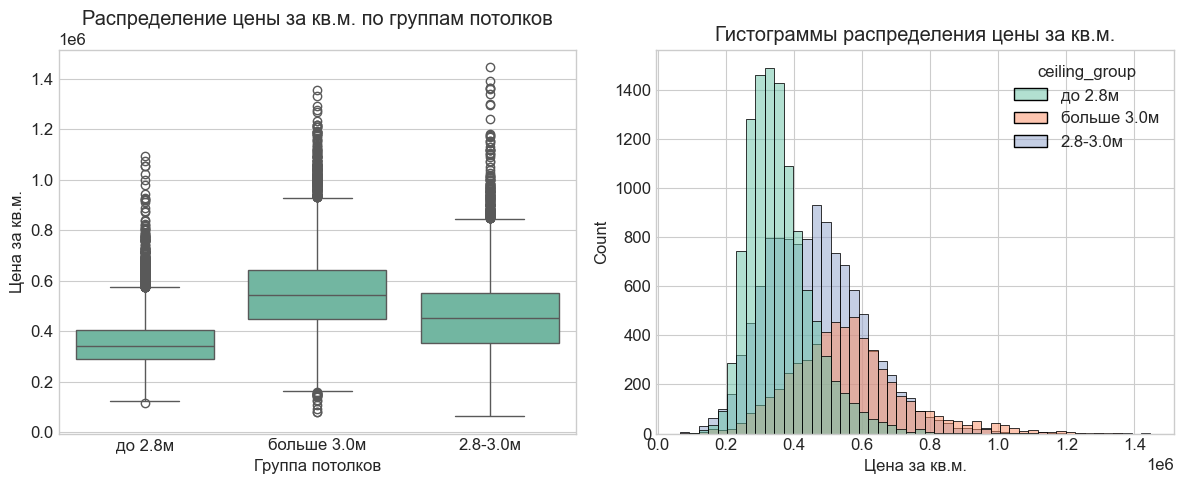

In [197]:
df_clean = df_hyp[
    (df_hyp['ceiling_height'] >= 2.0) & 
    (df_hyp['ceiling_height'] <= 10.0)
].copy()

print(f"Удалено записей: {len(df_hyp) - len(df_clean)}")
print(f"Осталось записей: {len(df_clean)}")

df_clean['price_per_sqm'] = df_clean['price'] / df_clean['total_area']

df_clean['ceiling_group'] = df_clean['ceiling_height'].apply(assign_ceiling_group)

print("\nРаспределение по группам:")
print(df_clean['ceiling_group'].value_counts())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean, x='ceiling_group', y='price_per_sqm')
plt.title('Распределение цены за кв.м. по группам потолков')
plt.xlabel('Группа потолков')
plt.ylabel('Цена за кв.м.')

plt.subplot(1, 2, 2)
sns.histplot(data=df_clean, x='price_per_sqm', hue='ceiling_group', bins=50, alpha=0.5)
plt.title('Гистограммы распределения цены за кв.м.')
plt.xlabel('Цена за кв.м.')

plt.tight_layout()
plt.show()

In [198]:
warnings.filterwarnings('ignore', message="scipy.stats.shapiro: For N > 5000.*")

Перед проверкой гипотез необходимо проверить, удовлетворяют ли распределения условиям (нормальность распределений, равенства дисперсий). В случае неудовлетворения необходимо применить поправки

In [199]:
print("\nПроверка нормальности (тест Шапиро-Уилка):")
for group in df_clean['ceiling_group'].unique():
    data = df_clean[df_clean['ceiling_group'] == group]['price_per_sqm']
    stat, p = stats.shapiro(data)
    print(f"{group}: статистика={stat:.4f}, p-value={p:.4f}")

groups_data = [df_clean[df_clean['ceiling_group'] == group]['price_per_sqm'] for group in df_clean['ceiling_group'].unique()]
stat, p_levene = levene(*groups_data)
print(f"\nТест Левена на равенство дисперсий: статистика={stat:.4f}, p-value={p_levene:.4f}")
print("Вывод: дисперсии", "равны" if p_levene > 0.05 else "не равны", "(при α=0.05)")

if p_levene > 0.05:
    print("\nРекомендуется использовать поправку Тьюки (дисперсии равны)")
else:
    print("\nРекомендуется использовать поправку Геймса-Хоувелла (дисперсии не равны)")


Проверка нормальности (тест Шапиро-Уилка):
до 2.8м: статистика=0.9237, p-value=0.0000
больше 3.0м: статистика=0.9677, p-value=0.0000
2.8-3.0м: статистика=0.9734, p-value=0.0000

Тест Левена на равенство дисперсий: статистика=1007.0529, p-value=0.0000
Вывод: дисперсии не равны (при α=0.05)

Рекомендуется использовать поправку Геймса-Хоувелла (дисперсии не равны)


Дисперсии не равны, поэтому необходимо применять ANOVA с поправкой Уэлча

In [200]:
welch_anova = pg.welch_anova(data=df_clean, dv='price_per_sqm', between='ceiling_group')
print("ANOVA с поправкой Уэлча:")
print(welch_anova)

ANOVA с поправкой Уэлча:
          Source  ddof1         ddof2            F  p_unc       np2
0  ceiling_group      2  13462.762036  4471.932357    0.0  0.233822


p-value равно нулю => **H0 отвергается**. Существуют статистически значимые различия в цене за квадратный метр между группами с разной высотой потолков

---

Чтобы определить разницу между группами, проведём попарные сравнения методом Геймса-Хоувелла

In [201]:
gh_result = pg.pairwise_gameshowell(
    data=df_clean, 
    dv='price_per_sqm', 
    between='ceiling_group'
)
gh_result

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,2.8-3.0м,больше 3.0м,462914.394230,558959.423045,-96045.028815,2634.545059,-36.456021,10184.364435,3.870237e-13,-0.61586
1,2.8-3.0м,до 2.8м,462914.394230,358306.735323,104607.658907,1668.680874,62.688834,20049.159106,0.000000e+00,0.82751
2,больше 3.0м,до 2.8м,558959.423045,358306.735323,200652.687722,2428.443958,82.626032,7758.745258,0.000000e+00,1.57945


Попарные сравнения также показывают значимые различия:  
- Цена за кв.м. за квартиру с высотой потолков выше 3м примерно на 100 т.р. больше, чем цена квартир из группы 2.8-3.0м
- Разница между группами >3.0 и <2.8 ещё более существенна - около 200 т.р.
- Разница между группами 2.8-3.0 или <2.8 составляет 100 т.р. в пользу первой группы

---

В целом результаты вполне предсказуемы - более высокие квартиры продаются дороже